# Y tế — bệnh viện, trung tâm y tế, phòng khám lớn

Nối tiếp `eda_truonghoc.ipynb`. Đầu vào: `poi_extended_7tinh_con_lai_sau_truonghoc.parquet`.

Lớp trường học phát hiện một thứ dùng lại được: khi một biến được mã hoá **hai lần bằng hai
hệ độc lập**, ta đo được tỷ lệ nhất trí — tức một con số precision thật. Lớp y tế có đúng
cấu hình đó, thậm chí sạch hơn: OSM có **hai họ tag song song** cho cùng một sự vật,
`amenity=hospital|clinic|doctors|dentist|pharmacy` và `healthcare=*`.

Nhưng lớp này có một chỗ khó mà trường học không có: **thang phân loại y tế là HAI CHIỀU
VUÔNG GÓC nhau**, không phải một chiều như cấp học.

| | trục LOẠI HÌNH | trục TUYẾN |
|---|---|---|
| ý nghĩa | *làm gì* | *phục vụ ai, quy mô nào* |
| bậc | bệnh viện · TTYT · phòng khám đa khoa · phòng khám chuyên khoa · trạm y tế · nhà thuốc | trung ương · tỉnh/thành · quận/huyện · phường/xã · tư nhân |

Một "Phòng khám đa khoa" tư nhân 2.000 m² lớn hơn một "Trạm y tế phường". Đọc một trục
thôi là sai. Và đề bài yêu cầu "bệnh viện, **phòng khám lớn**" — tức phải cắt theo cả hai.

In [1]:
import json
import re
import sys
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

EDA_DIR = ROOT / "data/qa/eda"
SCOPE = "7tinh"
LOP = "benhvien"
LOP_TRUOC = "truonghoc"

poi = pq.read_table(EDA_DIR / f"poi_extended_{SCOPE}_con_lai_sau_{LOP_TRUOC}.parquet").to_pandas()


def parse_tags(x):
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        try:
            return json.loads(x)
        except json.JSONDecodeError:
            return {}
    return {}


poi["tags_dict"] = poi["tags"].map(parse_tags)
td = poi["tags_dict"]


def strip_accents(s: str) -> str:
    s = unicodedata.normalize("NFD", str(s)).replace("đ", "d").replace("Đ", "D")
    return re.sub(r"[̀-ͯ]", "", s).lower()


def tag(key):
    return td.map(lambda t, k=key: str(t[k]).lower() if k in t else None)


for k in [
    "amenity",
    "healthcare",
    "building",
    "office",
    "shop",
    "landuse",
    "leisure",
    "tourism",
    "emergency",
    "historic",
    "man_made",
    "highway",
    "public_transport",
    "railway",
    "aeroway",
    "craft",
    "place",
    "military",
    "religion",
    "social_facility",
]:
    poi[k] = tag(k)
for k in ["healthcare:speciality", "operator:type", "operator", "beds", "capacity"]:
    poi[k.replace(":", "_")] = td.map(lambda t, k=k: t.get(k))

alt_names = td.map(
    lambda t: " ".join(
        v for v in (t.get("name:vi"), t.get("name:en"), t.get("alt_name"), t.get("old_name")) if v
    )
)
poi["name_norm"] = (
    poi["name"].fillna("").map(strip_accents) + " " + alt_names.map(strip_accents)
).str.strip()
name_norm = poi["name_norm"]

print(
    f"bộ vào: {len(poi):,} dòng | polygon {poi['is_area'].mean():.0%} | có tên {poi['name'].notna().mean():.0%}"
)

bộ vào: 150,712 dòng | polygon 33% | có tên 44%


## Chân dung hình thái

In [2]:
_uv = poi[
    poi["amenity"].isin(
        [
            "hospital",
            "clinic",
            "doctors",
            "dentist",
            "pharmacy",
            "veterinary",
            "nursing_home",
            "social_facility",
        ]
    )
    | poi["healthcare"].notna()
    | name_norm.str.contains(r"benh vien|phong kham|tram y te|trung tam y te|nha thuoc", na=False)
]
print(
    f"ứng viên thô: {len(_uv):,} | polygon {_uv['is_area'].mean():.0%}"
    f" | có tên {_uv['name'].notna().mean():.0%} | n_tags trung vị {_uv['n_tags'].median():.0f}"
)

print("\n── hai họ tag song song ──")
print(
    "  amenity :",
    poi["amenity"]
    .value_counts()[
        lambda s: s.index.isin(
            ["hospital", "clinic", "doctors", "dentist", "pharmacy", "veterinary", "nursing_home"]
        )
    ]
    .to_dict(),
)
print("  healthcare:", poi["healthcare"].value_counts().head(10).to_dict())
ca_hai = (
    poi["amenity"].isin(["hospital", "clinic", "doctors", "dentist", "pharmacy"])
    & poi["healthcare"].notna()
)
print(f"  CÓ CẢ HAI: {ca_hai.sum():,}  ← tập đối chứng chéo")

print("\n── các khoá quy mô / chuyên môn ──")
for k, nhan in [
    ("healthcare_speciality", "healthcare:speciality"),
    ("beds", "beds (số giường)"),
    ("emergency", "emergency=*"),
    ("operator_type", "operator:type"),
]:
    print(
        f"  {nhan:24s} {_uv[k].notna().sum():5,} ({_uv[k].notna().mean():5.1%})"
        f" → {_uv[k].value_counts().head(5).to_dict()}"
    )
print(
    "  → `beds` KHÔNG TỒN TẠI trong dữ liệu VN. Thước quy mô trực tiếp của ngành y tế"
    " (số giường bệnh) bằng 0 — cùng cảnh với `rooms` của lớp lưu trú."
)

ứng viên thô: 3,633 | polygon 31% | có tên 84% | n_tags trung vị 4

── hai họ tag song song ──
  amenity : {'pharmacy': 1341, 'hospital': 692, 'clinic': 523, 'dentist': 198, 'doctors': 137, 'veterinary': 51, 'nursing_home': 8}
  healthcare: {'pharmacy': 680, 'hospital': 612, 'clinic': 354, 'dentist': 155, 'doctor': 102, 'yes': 38, 'vaccination_centre': 9, 'alternative': 8, 'optometrist': 5, 'rehabilitation': 2}
  CÓ CẢ HAI: 1,898  ← tập đối chứng chéo

── các khoá quy mô / chuyên môn ──
  healthcare:speciality      165 ( 4.5%) → {'general': 62, 'plastic_surgery': 9, 'dermatology': 8, 'ophthalmology': 7, 'paediatrics': 6}
  beds (số giường)             0 ( 0.0%) → {}
  emergency=*                109 ( 3.0%) → {'yes': 93, 'no': 14, 'ambulance_station': 2}
  operator:type               77 ( 2.1%) → {'public/government': 18, 'private': 17, 'government': 14, 'public': 13, 'business': 9}
  → `beds` KHÔNG TỒN TẠI trong dữ liệu VN. Thước quy mô trực tiếp của ngành y tế (số giường bệnh) bằng 0 

### Chọn trục

1. **ĐỐI CHỨNG CHÉO `amenity` × `healthcare`** — kế thừa phương pháp của lớp trường học.
   Hai họ tag song song, cùng mô tả một sự vật, viết bởi cùng người map nhưng theo hai
   lược đồ khác nhau.
2. **HAI THANG VUÔNG GÓC: LOẠI HÌNH × TUYẾN**, cả hai đọc từ tên tiếng Việt. Đây là chỗ
   khác lớp trường học: cấp học là thang MỘT chiều, y tế là hai chiều.
3. **QUY MÔ** — và ở đây phải nói thẳng: `beds` bằng 0. Thước còn lại là diện tích polygon,
   `emergency=yes` (có khoa cấp cứu ⇒ là bệnh viện thật), và `healthcare:speciality`.

**Trục bị loại có lý do:** *sức hút* (lớp tham quan) — bệnh viện phục vụ bán kính hành
chính; *thừa kế thương hiệu* (lớp thương mại) — chuỗi nhà thuốc có brand nhưng chính nhà
thuốc lại nằm ngoài phạm vi lớp; *vai trò không gian* — vẫn dùng, nhưng chỉ để chống đếm
đôi chứ không để phân loại (khoa/dãy nhà trong khuôn viên bệnh viện).

## Bước 1 — filter MỎNG, ưu tiên recall

Tuyển cả nhà thuốc và phòng khám nhỏ — chúng là **mẫu số** của mọi phát biểu kiểu "x% cơ sở
y tế là loại lớn". Cắt phạm vi là việc của bước 3, có `drop_reason` riêng để tra ngược.

In [3]:
BLD_YT = ["hospital", "clinic", "healthcare", "pharmacy", "medical"]
YT_TAG = (
    poi["amenity"].isin(
        [
            "hospital",
            "clinic",
            "doctors",
            "dentist",
            "pharmacy",
            "veterinary",
            "nursing_home",
            "social_facility",
            "blood_donation",
        ]
    )
    | poi["healthcare"].notna()
    # `building` phải nhận CẢ HỌ giá trị y tế, không riêng `hospital` (sửa 2026-08-09).
    # Cổng recall độc lập bắt được 1 polygon `building=clinic` vô danh bị bỏ ngoài lớp:
    # bất đối xứng thuần tuý — cùng một khoá, một giá trị được tuyển, giá trị anh em
    # thì không. Ở 7 tỉnh là 1 dòng; ở 34 tỉnh đây là một nhóm.
    | poi["building"].isin(BLD_YT)
    | poi["emergency"].eq("ambulance_station")
    | poi["healthcare_speciality"].notna()
)
# Neo biên: `\bbv\b` là viết tắt bệnh viện nhưng cũng là chữ cái đầu của nhiều tên riêng;
# `mat` (mắt) khớp "Mật", "Mất"; `nhi` khớp "Nhị", "Nhì" — cả ba chỉ dùng trong CỤM.
YT_RX = (
    r"benh vien|\bbv \b|\bbvdk\b|benh xa|nha ho sinh|vien (?:tim|mat|nhi|phoi|huyet hoc|dinh duong|y hoc)"
    r"|phong kham|\bpk \b|\bpkdk\b|phong mach|phong chan tri|noi soi"
    r"|tram y te|\btyt\b|trung tam y te|\bttyt\b|trung tam cap cuu|trung tam kiem soat benh tat|\bcdc\b"
    r"|nha thuoc|hieu thuoc|quay thuoc|\bpharmacy\b|duoc pham"
    r"|nha khoa|rang ham mat|\bclinic\b|\bhospital\b|y hoc co truyen|dong y|cham cuu"
    r"|xet nghiem|chuan doan hinh anh|trung tam tiem chung|tiem chung"
    # ── từ vựng CHUYÊN KHOA (thẩm định 2026-08-09) ──
    # Đo trên bộ bỏ lại: "Y tế Dự phòng - 100-102 Bà Hom", "Trung tâm Dưỡng lão",
    # "Trung tâm nuôi dưỡng người tâm thần Đà Nẵng" lọt lưới vì mọi token tuyển ở trên
    # đều là tên LOẠI HÌNH ("bệnh viện", "phòng khám"). Cơ sở chuyên khoa tuyến tỉnh
    # thường chỉ ghi CHUYÊN KHOA. Đây là từ vựng dài hạn: phần lớn hiện chưa gom thêm
    # dòng nào ở 7 tỉnh, nhưng ở quy mô 34 tỉnh nó là cửa duy nhất cho nhóm này.
    # KHÔNG thêm `nhi dong` — "Nhị Đồng" (địa danh Đồng Nai) bỏ dấu trùng hoàn toàn,
    # cùng họ với bẫy `mat`/`nhi` ghi ở trên.
    r"|y te du phong|\btam than\b|\bduong lao\b|\bdieu duong\b|phuc hoi chuc nang"
    r"|\bphu san\b|\bsan nhi\b|\bung buou\b|\bda lieu\b|truyen mau|\bnoi tiet\b"
    r"|\bchinh hinh\b|\bnam hoc\b|\blao va benh phoi\b|\bbenh nhiet doi\b"
)
YT_NAME = name_norm.str.contains(YT_RX, regex=True, na=False)
YT_VONG_DOI = td.map(
    lambda t: any(
        ":" in k
        and k.split(":")[-1] in {"healthcare", "amenity"}
        and str(v).lower() in {"hospital", "clinic", "doctors", "pharmacy", "dentist"}
        for k, v in t.items()
    )
)

poi["is_yt"] = YT_TAG | YT_NAME | YT_VONG_DOI

BR = {"A tag y tế": YT_TAG, "B tên": YT_NAME, "C vòng đời": YT_VONG_DOI}
for ten, m in BR.items():
    print(f"  {ten:18s} {m.sum():6,}")
print(f"  {'HỢP':18s} {poi['is_yt'].sum():6,} / {len(poi):,} ({poi['is_yt'].mean():.2%})")
print("\nđóng góp RIÊNG của từng nhánh:")
for ten, m in BR.items():
    khac = np.logical_or.reduce([v.values for k, v in BR.items() if k != ten])
    chi_no = m & ~khac
    print(f"  {ten:18s} {chi_no.sum():5,}  {poi.loc[chi_no, 'name'].dropna().head(3).tolist()}")

  A tag y tế          4,121
  B tên               2,252
  C vòng đời              0
  HỢP                 4,728 / 150,712 (3.14%)

đóng góp RIÊNG của từng nhánh:
  A tag y tế         2,476  ['Trung Tam Bac Si Gia Dinh Da Nang', 'Trung Tam Phuc Hoi Co Nhi Suy Dinh Duong Da Nang', 'HT Chí Linh']
  B tên                607  ['Bệnh viện Xanh Pôn - 12 Chu Văn An', 'Bệnh viện Da liễu Trung ương', 'Đối diện Bệnh viện Thanh Nhàn']
  C vòng đời             0  []


### Cổng recall 1 — phủ tag chắc chắn

In [4]:
CHECKS = {
    "amenity=hospital": poi["amenity"].eq("hospital"),
    "amenity=clinic": poi["amenity"].eq("clinic"),
    "amenity=doctors": poi["amenity"].eq("doctors"),
    "amenity=dentist": poi["amenity"].eq("dentist"),
    "amenity=pharmacy": poi["amenity"].eq("pharmacy"),
    "healthcare=*": poi["healthcare"].notna(),
    "building=hospital": poi["building"].eq("hospital"),
    "có healthcare:speciality": poi["healthcare_speciality"].notna(),
    "tên 'bệnh viện'": name_norm.str.contains(r"benh vien", na=False),
    "tên 'phòng khám'": name_norm.str.contains(r"phong kham", na=False),
    "tên 'trạm y tế'": name_norm.str.contains(r"tram y te", na=False),
    "tên 'nhà thuốc'": name_norm.str.contains(r"nha thuoc|hieu thuoc|quay thuoc", na=False),
}
mat = 0
for ten, m in CHECKS.items():
    thieu = int((m & ~poi["is_yt"]).sum())
    mat += thieu
    print(f"  {ten:28s} giữ {(m & poi['is_yt']).sum():>6,}/{m.sum():<6,}  mất {thieu}")
assert mat == 0, f"recall thủng: mất {mat} dòng"
print(f"\n✓ phủ 100% trên {len(CHECKS)} phép thử")

  amenity=hospital             giữ    692/692     mất 0
  amenity=clinic               giữ    523/523     mất 0
  amenity=doctors              giữ    137/137     mất 0
  amenity=dentist              giữ    198/198     mất 0
  amenity=pharmacy             giữ  1,341/1,341   mất 0
  healthcare=*                 giữ  1,977/1,977   mất 0
  building=hospital            giữ  1,054/1,054   mất 0
  có healthcare:speciality     giữ    165/165     mất 0
  tên 'bệnh viện'              giữ    805/805     mất 0
  tên 'phòng khám'             giữ    233/233     mất 0
  tên 'trạm y tế'              giữ    386/386     mất 0
  tên 'nhà thuốc'              giữ    356/356     mất 0

✓ phủ 100% trên 12 phép thử


### Cổng recall 2 — ĐỘC LẬP

In [5]:
_bo = poi[~poi["is_yt"]]
_ten = _bo["name_norm"]
_tags = _bo["tags_dict"]

DAU_DO_CUNG = {
    # `emergency=*` KHÔNG dùng nguyên khoá: trong OSM nó phủ cả trụ nước chữa cháy, chòi cứu
    # hộ bãi biển, điểm tập kết ("Ga Tàu Thuỷ Bình An", "Đài cứu hộ" — 160 dòng). Chỉ ba giá
    # trị dưới đây là Y TẾ. Bài học: một KHOÁ không phải một khái niệm; phải đọc GIÁ TRỊ.
    # Lọc dần qua ba vòng, và mỗi vòng là một nấc của cùng một bài học:
    #   khoá `emergency` → phủ cả trụ nước, chòi cứu hộ (160 dòng, không cái nào là y tế)
    #   giá trị `defibrillator` → một THIẾT BỊ gắn tường, không phải cơ sở
    #   giá trị `emergency_ward_entrance` → một CỬA VÀO, không phải cơ sở
    # Chỉ `ambulance_station` mới là một cơ sở đứng riêng. Cùng họ với `tourism=information`
    # của lớp tham quan: nguồn mô tả một BỘ PHẬN, ta cần một VẬT THỂ.
    # ĐẦU DÒ ĐỘC LẬP THẬT SỰ (sửa 2026-08-09). Chỗ này TRƯỚC ĐÂY là
    # `emergency=ambulance_station` — nhưng chính điều kiện đó nằm trong `YT_TAG`,
    # nên nó = 0 VĨNH VIỄN bất kể dữ liệu thế nào: một tautology, không đo được gì.
    # Một cổng recall chỉ có giá trị khi nó dùng TÍN HIỆU KHÔNG THAM GIA TUYỂN.
    # Thay bằng: hình thái (polygon lớn) × từ vựng lâm sàng, giao với `building`
    # tự khai — không nhánh nào trong ba nhánh tuyển đọc tổ hợp này.
    # `building=hospital` và `healthcare:speciality` KHÔNG được dùng ở đây — cả hai
    # đã nằm trong YT_TAG, dùng lại là lặp đúng lỗi vòng tròn vừa gỡ.
    # Tripwire TỰ BẢO TRÌ: bắt mọi GIÁ TRỊ `building` mang nghĩa y tế mà danh mục
    # tuyển `BLD_YT` chưa liệt kê. Không lặp lại danh mục nên không thể thành vòng
    # tròn, và tự đỏ khi OSM sinh giá trị mới ở tỉnh khác.
    "`building` nghĩa y tế nhưng NGOÀI danh mục tuyển": _bo["building"]
    .fillna("")
    .str.contains(r"hospital|clinic|health|medic|pharma|ambulance|nursing", na=False)
    & ~_bo["building"].isin(BLD_YT),
    "khoá `medical_system` / `health_facility:*`": _tags.map(
        lambda t: bool(t.get("medical_system"))
        or any(k.startswith("health_facility") for k in t)
    ),
    "có khoá `health_*` / `medical_*`": _tags.map(
        lambda t: any(k.startswith(("health_", "medical_")) for k in t)
    )
    & _bo["amenity"].isna() & _bo["shop"].isna() & _bo["office"].isna(),
    "tên có 'y tế / khám chữa bệnh' + polygon": _ten.str.contains(
        r"\by te\b|kham chua benh", na=False
    )
    & _bo["is_area"]
    # trừ cơ quan quản lý và văn phòng đại diện — thuộc lớp hành chính
    & ~_ten.str.contains(
        r"^(?:so|phong|bo|cuc|vu|ban|chi cuc)\s|van phong|dai dien|cong ty|\bcty\b|thiet bi",
        na=False,
    ),
}
DAU_DO_MEM = {
    # `operator` là CHỦ SỞ HỮU, không phải LOẠI CÔNG TRÌNH — bài học lặp lại từ lớp trường
    # học ("Hầm giữ xe" do đại học vận hành). Ở đây: "Nhà Tang lễ Quốc gia" do bệnh viện
    # vận hành, "Viện Sức khoẻ nghề nghiệp" là viện nghiên cứu.
    "`operator` là Sở/Bộ Y tế hoặc Bệnh viện": _bo["operator"]
    .fillna("")
    .map(strip_accents)
    .str.contains(r"\bbenh vien\b|\bso y te\b|\bbo y te\b|\btrung tam y te\b", na=False),
    "`emergency` ở giá trị PHI y tế (trụ nước, chòi cứu hộ)": _bo["emergency"].notna()
    & ~_bo["emergency"].eq("ambulance_station"),
    # từ vựng lâm sàng còn sót — MỀM vì bỏ dấu làm "Tam Thắng" đụng "tâm thần",
    # "Học viện Quân y" là TRƯỜNG. Theo dõi bằng mắt, không chặn.
    "từ vựng lâm sàng còn sót ngoài lớp": _ten.str.contains(
        r"\bcap cuu\b|\bso cuu\b|\bquan y\b|\bbac si\b|\bdental\b|\bmedical\b", na=False
    ),
    "tên có 'viện' (đa số là viện nghiên cứu / học viện)": _ten.str.contains(r"\bvien \b", na=False),
    "tên có 'dược' (đa số là công ty dược)": _ten.str.contains(r"\bduoc\b", na=False),
    "tên có 'sở/phòng y tế' → lớp hành chính": _ten.str.contains(r"(?:so|phong) y te", na=False),
}

_thung = 0
print("── ĐẦU DÒ CỨNG (phải = 0) ──")
for ten, m in DAU_DO_CUNG.items():
    n = int(m.sum())
    _thung += n
    print(
        f"  {'✗' if n else '✓'} {ten:52s} {n:4,}  {_bo.loc[m, 'name'].dropna().head(3).tolist() if n else []}"
    )
print("\n── ĐẦU DÒ MỀM (theo dõi, không chặn) ──")
for ten, m in DAU_DO_MEM.items():
    n = int(m.sum())
    print(f"  ⊙ {ten:52s} {n:4,}  {_bo.loc[m, 'name'].dropna().head(3).tolist() if n else []}")
assert _thung == 0, f"recall thủng {_thung} dòng ở đầu dò CỨNG"
print("\n✓ cổng độc lập: mọi đầu dò cứng = 0")

── ĐẦU DÒ CỨNG (phải = 0) ──
  ✓ `building` nghĩa y tế nhưng NGOÀI danh mục tuyển        0  []
  ✓ khoá `medical_system` / `health_facility:*`             0  []
  ✓ có khoá `health_*` / `medical_*`                        0  []
  ✓ tên có 'y tế / khám chữa bệnh' + polygon                0  []

── ĐẦU DÒ MỀM (theo dõi, không chặn) ──
  ⊙ `operator` là Sở/Bộ Y tế hoặc Bệnh viện                 7  ['Cục Bà mẹ và Trẻ em', 'Nhà Tang lễ Quốc gia', 'Chi cục Dân số, Trẻ em và Phòng, chống tệ nạn xã hội Hà Nội']
  ⊙ `emergency` ở giá trị PHI y tế (trụ nước, chòi cứu hộ)  160  ['Ga Tàu Thuỷ Bình An', 'Đài cứu hộ', 'Cấp Cứu Bờ Biển số 2']
  ⊙ từ vựng lâm sàng còn sót ngoài lớp                     10  ['Trạm Xe Bus Học Viện Quân Y', 'Học viện Quân y', 'Học viện Quân Y - Phùng Hưng (Hà Đông)']
  ⊙ tên có 'viện' (đa số là viện nghiên cứu / học viện)   506  ['Yên Viên', '477 Nguyễn Trãi - Học viện Khoa học Xã hội', 'Học viện công nghệ bưu chính viễn thông - Trần Phú (Hà Đông)']
  ⊙ tên có 'dược' (đa s

In [6]:
yt = poi[poi["is_yt"]].copy()
out_b1 = EDA_DIR / f"poi_{LOP}_{SCOPE}_b1.parquet"
yt.drop(columns="tags_dict").to_parquet(out_b1, index=False)
print(
    f"→ {out_b1.name}: {len(yt):,} dòng | polygon {yt['is_area'].mean():.0%}"
    f" | có tên {yt['name'].notna().mean():.0%}"
)

→ poi_benhvien_7tinh_b1.parquet: 4,728 dòng | polygon 46% | có tên 70%


## Bước 2 — đối chứng chéo hai họ tag, rồi dựng HAI thang

In [7]:
import matplotlib.pyplot as plt

BLUE, ORANGE, GREEN = "#2a78d6", "#eb6834", "#1baf7a"
GRAY = "#b8b7b2"
INK, MUTED, BG = "#0b0b0b", "#52514e", "#fcfcfb"
plt.rcParams.update(
    {
        "figure.facecolor": BG,
        "axes.facecolor": BG,
        "savefig.facecolor": BG,
        "axes.edgecolor": "#d9d8d4",
        "axes.grid": True,
        "grid.color": "#ebeae6",
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "text.color": INK,
        "axes.labelcolor": MUTED,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 110,
    }
)


def fmt(x, n=0):
    return f"{x:,.{n}f}".translate(str.maketrans(",.", ".,"))


# ĐỐI CHỨNG CHÉO. Chuẩn hoá hai lược đồ về CÙNG một bảng từ trước khi so — nếu không thì
# `amenity=doctors` vs `healthcare=doctor` bị tính là bất đồng chỉ vì một chữ "s".
CHUAN = {
    "hospital": "BENH_VIEN",
    "clinic": "PHONG_KHAM",
    "doctors": "PHONG_KHAM",
    "doctor": "PHONG_KHAM",
    "dentist": "NHA_KHOA",
    "pharmacy": "NHA_THUOC",
    "centre": "PHONG_KHAM",
    "center": "PHONG_KHAM",
}
yt["loai_amenity"] = yt["amenity"].map(CHUAN)
yt["loai_healthcare"] = yt["healthcare"].map(CHUAN)
ca_hai = yt["loai_amenity"].notna() & yt["loai_healthcare"].notna()
khop = yt.loc[ca_hai, "loai_amenity"] == yt.loc[ca_hai, "loai_healthcare"]
print(f"── ĐỐI CHỨNG CHÉO `amenity` × `healthcare` trên {int(ca_hai.sum()):,} dòng có cả hai ──")
print(f"NHẤT TRÍ: {khop.sum():,}/{len(khop):,} = {khop.mean():.1%}")
print()
print(pd.crosstab(yt.loc[ca_hai, "loai_amenity"], yt.loc[ca_hai, "loai_healthcare"]).to_string())
yt["loai_xung_dot"] = False
yt.loc[ca_hai, "loai_xung_dot"] = ~khop
print(f"\nbất đồng: {int(yt['loai_xung_dot'].sum())} dòng")
print(yt.loc[yt["loai_xung_dot"], ["name", "amenity", "healthcare"]].head(8).to_string())

── ĐỐI CHỨNG CHÉO `amenity` × `healthcare` trên 1,893 dòng có cả hai ──
NHẤT TRÍ: 1,889/1,893 = 99.8%

loai_healthcare  BENH_VIEN  NHA_KHOA  NHA_THUOC  PHONG_KHAM
loai_amenity                                               
BENH_VIEN              611         0          0           2
NHA_KHOA                 0       154          0           1
NHA_THUOC                0         0        677           0
PHONG_KHAM               0         1          0         447

bất đồng: 4 dòng
                                 name   amenity healthcare
3780               Trạm y tế Hưng Lợi  hospital     clinic
39835               Nha Khoa Lê Hoàng   dentist     clinic
95001           Nha Khoa Thiện Tâm An  hospital     clinic
141196  Răng hàm mặt Sài Gòn Biên Hòa   doctors    dentist


In [8]:
# [DATA] sinh cột: loai_yt, tuyen_yt
# THANG 1 — LOẠI HÌNH. Gán từ CỤ THỂ xuống CHUNG.
#
# THỨ TỰ Ở ĐÂY LÀ MỘT QUYẾT ĐỊNH, KHÔNG PHẢI TRÌNH BÀY (sửa 2026-08-09).
# Trước đây vòng đọc TÊN chạy trước rồi mới lấp bằng TAG. Hệ quả: "Bệnh viện Thú y
# Petpro" khớp `benh vien` ở dòng đầu → nhãn BENH_VIEN, và không bao giờ xuống tới
# `amenity=veterinary` → THU_Y. LUẬT 4 (cắt theo NHÃN) vì thế trượt 16 dòng thú y,
# 8 trong số đó nằm trong final dưới nhãn BENH_VIEN.
#
# Nguyên tắc rút ra: TÊN mô tả *hình thức tổ chức* ("bệnh viện", "phòng khám"),
# TAG mô tả *đối tượng phục vụ* (người / thú). Hai chiều khác nhau, nên chiều nào
# CỤ THỂ hơn phải chạy trước. THU_Y là một chiều RIÊNG — tách khỏi vòng LOAI_YT.
THU_Y_RX = r"\bthu y\b|thu cung|\bpet\b|petshop|pet shop|petcare|pet care|animal hospital"
la_thu_y = yt["amenity"].eq("veterinary") | yt["name_norm"].str.contains(THU_Y_RX, na=False)

# CHIỀU THỨ HAI: BẢO TRỢ XÃ HỘI ≠ Y TẾ (thêm 2026-08-09).
# Bản trước map thẳng `amenity=social_facility|nursing_home` → TRUNG_TAM_Y_TE. Đo lại:
# 56 dòng `social_facility` gồm "Trại trẻ mồ côi An Thạnh", "Làng Trẻ em SOS", "Bếp Ăn
# 0 Đồng Chú Long", "Viện Nghiên cứu Xã hội (iSEE)" — bảo trợ xã hội, không phải cơ sở
# khám chữa bệnh. Và `amenity=nursing_home` (đã bị OSM khai tử, thay bằng
# `social_facility=nursing_home`) chỉ đúng 1/8: 7 dòng còn lại là "Nhà Ba Chi (Trường
# Gà)", "Rẫy", "Massaga Trường Giang" — tag rác một dòng, không tag nào khác chống lưng.
#
# Đây LẠI LÀ bài học `emergency` mà chính notebook này giảng ở bước 1, mắc lại ở khoá
# thứ ba: một KHOÁ không phải một KHÁI NIỆM. `social_facility` có sẵn KHOÁ CON mang
# giá trị — phải đọc nó. Chỗ nào khoá con trống thì đọc TÊN.
# KHÔNG xoá nhóm này: viện dưỡng lão là cầu sạc thật, và trại trẻ mồ côi là dữ liệu
# thật của một lớp khác. Chỉ tách NHÃN để downstream không đếm chúng là bệnh viện.
SF_YT = ["nursing_home", "assisted_living", "hospice", "ambulatory_care"]
XH_YT_RX = (
    r"\bduong lao\b|\bdieu duong\b|phuc hoi chuc nang|nguoi cao tuoi|\ban duong\b"
    r"|\bhospice\b|cai nghien|nuoi duong nguoi (?:gia|tam than)"
)
# Khoá con `social_facility` cũng sai được: "Trại trẻ mồ côi An Thạnh" và "Mái ấm Pháp
# Hoa" mang `assisted_living`/`nursing_home`. Khi một tag ĐÃ ĐO ĐƯỢC là không tin cậy
# thì TÊN thắng TAG — ngược chiều mặc định của cả chuỗi, và đó là lý do phải ghi rõ.
XH_KHONG_YT_RX = (
    r"mo coi|co nhi|\blang tre\b|\bmai am\b|\btre em\b|thieu nien|bao tro"
    r"|\bbep an\b|tu thien|nguoi mu|khuyet tat|cong tac xa hoi|\bnha tro\b"
)
la_bao_tro = yt["amenity"].isin(["social_facility", "nursing_home"])
xh_la_yt = np.select(
    [
        yt["name_norm"].str.contains(XH_YT_RX, na=False),
        yt["name_norm"].str.contains(XH_KHONG_YT_RX, na=False),
        yt["social_facility"].isin(SF_YT),
    ],
    [True, False, True],
    default=False,
)
xh_la_yt = pd.Series(xh_la_yt, index=yt.index)

LOAI_YT = [
    ("BENH_VIEN", r"benh vien|\bbv \b|\bbvdk\b|benh xa|vien (?:tim|mat|nhi|phoi|huyet hoc|y hoc)"),
    (
        "TRUNG_TAM_Y_TE",
        r"trung tam y te|\bttyt\b|trung tam cap cuu|trung tam kiem soat benh tat|\bcdc\b"
        r"|trung tam tiem chung|nha ho sinh|y te du phong|\bduong lao\b|\bdieu duong\b",
    ),
    ("TRAM_Y_TE", r"tram y te|\btyt\b"),
    ("PK_DA_KHOA", r"phong kham da khoa|\bpkdk\b|da khoa"),
    (
        "PK_CHUYEN_KHOA",
        r"phong kham|\bpk \b|phong mach|nha khoa|rang ham mat|chuyen khoa"
        r"|xet nghiem|chuan doan hinh anh|noi soi|y hoc co truyen|dong y|cham cuu",
    ),
    ("NHA_THUOC", r"nha thuoc|hieu thuoc|quay thuoc|\bpharmacy\b"),
]
loai = pd.Series(None, index=yt.index, dtype=object)
loai[la_thu_y] = "THU_Y"  # ← chiều ĐỐI TƯỢNG, quyết trước chiều HÌNH THỨC
for val, rx in LOAI_YT:
    loai[yt["name_norm"].str.contains(rx, na=False) & loai.isna()] = val
# bảo trợ xã hội: sau vòng TÊN (một "Bệnh viện" thật vẫn thắng), trước vòng TAG
_bt = la_bao_tro & loai.isna()
loai[_bt] = np.where(xh_la_yt[_bt], "TRUNG_TAM_Y_TE", "CS_XA_HOI")
# lấp bằng TAG cho dòng tên không nói
loai = loai.fillna(
    yt["amenity"].map(
        {
            "hospital": "BENH_VIEN",
            "clinic": "PK_DA_KHOA",
            "doctors": "PK_CHUYEN_KHOA",
            "dentist": "PK_CHUYEN_KHOA",
            "pharmacy": "NHA_THUOC",
            "veterinary": "THU_Y",
        }
    )
)
loai = loai.fillna(
    yt["healthcare"].map(
        {
            "hospital": "BENH_VIEN",
            "clinic": "PK_DA_KHOA",
            "doctor": "PK_CHUYEN_KHOA",
            "dentist": "PK_CHUYEN_KHOA",
            "pharmacy": "NHA_THUOC",
            "veterinary": "THU_Y",
        }
    )
)
yt["loai_yt"] = loai.fillna("KHONG_XAC_DINH")

# ── THANG 2 — TUYẾN. Vuông góc với thang trên. ────────────────────────────────
# VIẾT LẠI 2026-08-09. Bản cũ đòi "benh vien" ĐỨNG SÁT "tinh|thanh pho", nên
# "Bệnh viện **Mắt** Thành phố Hồ Chí Minh" trượt bậc TINH_THANH và rơi xuống
# QUAN_HUYEN (chỉ cần có chữ "thành phố"). Kết quả: TINH_THANH = 4 dòng trên toàn
# bộ final, rỗng vì LỖI CHỨ KHÔNG VÌ THIẾU DỮ LIỆU — loại sai nguy hiểm nhất.
#
# Cách sửa mang tính mở rộng: KHÔNG dựa vào vị trí chữ, mà dựa vào DANH MỤC ĐƠN VỊ
# HÀNH CHÍNH. "thành phố X" là tuyến tỉnh khi và chỉ khi X là một tỉnh/thành trực
# thuộc TW. Danh mục 34 đơn vị đọc thẳng từ `store/admin/provinces.parquet` (niên
# bản 16/6/2025) nên tự cập nhật theo mọi lần sáp nhập; danh mục 63 tên CŨ là sự
# kiện lịch sử, không đổi nữa, nên viết cứng — OSM còn đầy tên trước sáp nhập.
_prov = pq.read_table(ROOT / "store/admin/provinces.parquet", columns=["province_name"])
TINH_HIEN = [
    strip_accents(re.sub(r"^(?:Tỉnh|Thành phố)\s+", "", p))
    for p in _prov.to_pandas()["province_name"]
]
TINH_CU = [
    strip_accents(x)
    for x in [
        "An Giang", "Bà Rịa Vũng Tàu", "Bắc Giang", "Bắc Kạn", "Bạc Liêu", "Bến Tre",
        "Bình Định", "Bình Dương", "Bình Phước", "Bình Thuận", "Đắk Nông", "Hà Giang",
        "Hà Nam", "Hải Dương", "Hậu Giang", "Hòa Bình", "Kiên Giang", "Kon Tum",
        "Long An", "Nam Định", "Ninh Thuận", "Phú Yên", "Quảng Bình", "Quảng Nam",
        "Sóc Trăng", "Thái Bình", "Thừa Thiên Huế", "Tiền Giang", "Trà Vinh",
        "Vĩnh Phúc", "Yên Bái",
    ]
]
TEN_TINH = sorted(set(TINH_HIEN + TINH_CU), key=len, reverse=True)
RX_TEN_TINH = "|".join(re.escape(t) for t in TEN_TINH)
# "thành phố" ĐỨNG CUỐI tên (không có tên riêng theo sau) = thành phố CHỦ QUẢN của
# chính POI đó — "Bệnh viện Nhi đồng Thành phố", "Bệnh viện Mắt Thành phố".
# CHỈ "thành phố", KHÔNG có "tỉnh" trần. Đo 2026-08-09: nhánh `\btinh\s*$` bắt 3 dòng
# và SAI cả 3 — "Bệnh viện Tuệ Tĩnh", "Phòng Chẩn Trị Đông Y Tuệ Tĩnh", "Trạm Y tế xã
# Phước Tỉnh". Bỏ dấu làm "tỉnh" (đơn vị hành chính) trùng khít "Tĩnh"/"Tịnh" (âm tiết
# tên riêng rất phổ biến). Token "tinh" TRẦN không bao giờ an toàn: nó chỉ dùng được khi
# ĐỨNG TRƯỚC một tên tỉnh có thật, hoặc ĐỨNG SAU "bệnh viện|đa khoa".
# "thành phố" thì an toàn — hai âm tiết, không trùng tên riêng nào.
RX_TP_TRONG = r"\bthanh pho\s*(?:[-–,(]|$)"
TUYEN_YT = [
    (
        "TRUNG_UONG",
        r"trung uong|\bquan y (?:vien)?\b|\b108\b|bach mai|cho ray|viet duc|\bk\b co so"
        r"|\bbo y te\b|\bviet nam\b\s*$",
    ),
    (
        "TINH_THANH",
        rf"\b(?:tinh|thanh pho|tp\.?)\s+(?:{RX_TEN_TINH})\b"
        rf"|benh vien (?:tinh|thanh pho)|\bda khoa (?:tinh|thanh pho)\b|\bso y te\b"
        rf"|{RX_TP_TRONG}",
    ),
    # `\bquan [a-z]` cũ nuốt "quân y", "quân dân y", "quân đội", "quản lý" (23 dòng đo
    # 2026-08-09); `\bxa \b` nuốt "xã hội" (9 dòng). Chặn bằng lookahead — danh sách
    # từ-chặn ngắn và ổn định, rẻ hơn nhiều so với liệt kê tên quận.
    (
        "QUAN_HUYEN",
        r"\bquan \d|\bquan (?!y\b|dan\b|doi\b|ly\b|trac\b|su\b|the\b|khu\b|diem\b)[a-z]"
        r"|\bhuyen \b|\bthi xa\b|\bthanh pho \b",
    ),
    ("PHUONG_XA", r"\bphuong \b|\bxa (?!hoi\b)\w|\bthi tran\b"),
    (
        "TU_NHAN",
        r"quoc te|\bdr\b|\bvinmec\b|\bhoan my\b|\bfv\b|\bcolumbia\b|\bfamily\b|\btam anh\b",
    ),
]
tuyen = pd.Series(None, index=yt.index, dtype=object)
for val, rx in TUYEN_YT:
    tuyen[yt["name_norm"].str.contains(rx, na=False) & tuyen.isna()] = val
yt["tuyen_yt"] = tuyen.fillna("KHONG_KHAI")

print(f"danh mục tỉnh/thành dùng cho thang TUYẾN: {len(TEN_TINH)} tên (34 hiện + tên cũ)")
print("\n── THANG 1: LOẠI HÌNH ──")
print(yt["loai_yt"].value_counts().to_string())
print("\n── THANG 2: TUYẾN ──")
print(yt["tuyen_yt"].value_counts().to_string())
print("\n── hai thang có VUÔNG GÓC thật không? ──")
print(pd.crosstab(yt["loai_yt"], yt["tuyen_yt"]).to_string())


danh mục tỉnh/thành dùng cho thang TUYẾN: 64 tên (34 hiện + tên cũ)

── THANG 1: LOẠI HÌNH ──
loai_yt
NHA_THUOC         1363
KHONG_XAC_DINH    1072
BENH_VIEN          900
PK_CHUYEN_KHOA     468
TRAM_Y_TE          382
PK_DA_KHOA         241
TRUNG_TAM_Y_TE     204
THU_Y               56
CS_XA_HOI           42

── THANG 2: TUYẾN ──
tuyen_yt
KHONG_KHAI    3928
PHUONG_XA      368
QUAN_HUYEN     157
TU_NHAN        104
TRUNG_UONG      91
TINH_THANH      80

── hai thang có VUÔNG GÓC thật không? ──
tuyen_yt        KHONG_KHAI  PHUONG_XA  QUAN_HUYEN  TINH_THANH  TRUNG_UONG  TU_NHAN
loai_yt                                                                           
BENH_VIEN              609         16          80          57          79       59
CS_XA_HOI               39          0           0           3           0        0
KHONG_XAC_DINH        1057          0           0           2           7        6
NHA_THUOC             1334         15           6           6           1        1
PK_CHU

                   n  polygon    dt_tv  co_cap_cuu  co_chuyen_khoa
loai_yt                                                           
BENH_VIEN        900     53.0  12007.0         9.9             9.9
TRUNG_TAM_Y_TE   204     76.0  12858.0         0.0             2.9
PK_DA_KHOA       241     44.0    323.0         0.4             9.1
PK_CHUYEN_KHOA   468     12.0    107.0         0.2             8.3
TRAM_Y_TE        382     62.0   1079.0         0.3             0.8
NHA_THUOC       1363      7.0     74.0         0.0             0.1
THU_Y             56     14.0    599.0         1.8             0.0
CS_XA_HOI         42     60.0   8431.0         0.0             0.0
KHONG_XAC_DINH  1072     95.0    645.0         0.2             0.5

→ `emergency=yes` là nhân chứng độc lập mạnh nhất: có khoa cấp cứu thì gần như chắc chắn là bệnh viện. Diện tích xác nhận cùng thứ tự.


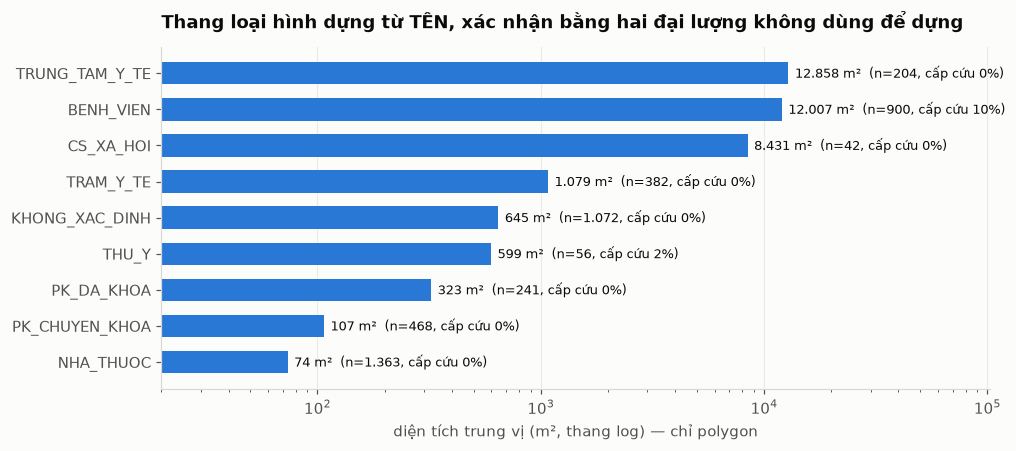

In [9]:
# KIỂM ĐỊNH ĐỘC LẬP — diện tích và `emergency`. Cả hai không tham gia dựng thang nào ở trên.
LOAI_ORDER = [
    "BENH_VIEN",
    "TRUNG_TAM_Y_TE",
    "PK_DA_KHOA",
    "PK_CHUYEN_KHOA",
    "TRAM_Y_TE",
    "NHA_THUOC",
    "THU_Y",
    "CS_XA_HOI",
    "KHONG_XAC_DINH",
]
bang = (
    yt.groupby("loai_yt")
    .agg(
        n=("uid", "size"),
        polygon=("is_area", "mean"),
        dt_tv=("area_m2", lambda s: s[s > 0].median()),
        co_cap_cuu=("emergency", lambda s: s.eq("yes").mean()),
        co_chuyen_khoa=("healthcare_speciality", lambda s: s.notna().mean()),
    )
    .reindex([c for c in LOAI_ORDER if c in yt["loai_yt"].unique()])
)
print(
    bang.assign(
        polygon=lambda d: (d.polygon * 100).round(0),
        co_cap_cuu=lambda d: (d.co_cap_cuu * 100).round(1),
        co_chuyen_khoa=lambda d: (d.co_chuyen_khoa * 100).round(1),
        dt_tv=lambda d: d.dt_tv.round(0),
    ).to_string()
)
print(
    "\n→ `emergency=yes` là nhân chứng độc lập mạnh nhất: có khoa cấp cứu thì gần như chắc"
    " chắn là bệnh viện. Diện tích xác nhận cùng thứ tự."
)

fig, ax = plt.subplots(figsize=(9.4, 4.2))
b = bang.dropna(subset=["dt_tv"]).sort_values("dt_tv")
ax.barh(b.index, b["dt_tv"], color=BLUE, height=0.62)
for y, (v, n, cc) in enumerate(zip(b["dt_tv"], b["n"], b["co_cap_cuu"])):
    ax.text(
        v * 1.07,
        y,
        f"{fmt(v)} m²  (n={fmt(n)}, cấp cứu {cc:.0%})",
        va="center",
        fontsize=8.5,
        color=INK,
    )
ax.set_xscale("log")
ax.set_xlim(20, float(b["dt_tv"].max()) * 8)
ax.grid(axis="y", visible=False)
ax.set_xlabel("diện tích trung vị (m², thang log) — chỉ polygon")
ax.set_title(
    "Thang loại hình dựng từ TÊN, xác nhận bằng hai đại lượng không dùng để dựng",
    pad=12,
    loc="left",
)
fig.tight_layout()
plt.show()

### REVIEW — hai thang và phạm vi lớp

**Soi gì:** đối chứng chéo `amenity` × `healthcare`; hai thang loại hình / tuyến; kiểm định
bằng diện tích và `emergency`.

**Tìm được:**
- Hai họ tag OSM **nhất trí rất cao** sau khi chuẩn hoá về cùng bảng từ. Phần bất đồng nhỏ
  và có cấu trúc (chủ yếu `clinic` ↔ `doctors`, ranh giới vốn mờ trong thực tế).
- **`beds` = 0 dòng.** Thước quy mô trực tiếp của ngành y tế không tồn tại trong dữ liệu VN
  — cùng cảnh `rooms` ở lớp lưu trú. Phải thay bằng diện tích + `emergency`.
- **`emergency=yes` là nhân chứng độc lập tốt nhất** cho "bệnh viện thật".
- Hai thang **thật sự vuông góc**: có phòng khám tư quy mô lớn và có trạm y tế phường nhỏ,
  bảng chéo không tập trung vào đường chéo.

**Quyết định phạm vi (đề bài: "bệnh viện, phòng khám lớn"):** giữ `BENH_VIEN`,
`TRUNG_TAM_Y_TE`, `PK_DA_KHOA`; **cắt** `NHA_THUOC` và `THU_Y`; `PK_CHUYEN_KHOA` và
`TRAM_Y_TE` **giữ nhưng cắm cờ quy mô** — phòng khám nha khoa 60 m² và phòng khám đa khoa
tư 2.000 m² không thể cùng một nhãn.

→ TỰ PHÊ DUYỆT, đi tiếp.

## Bước 3 — precision: mỗi luật một cell

In [10]:
candidates = yt.copy()
remaining = candidates.copy()
remaining["mixed_use"] = False
removed_parts = []


def co_bang_chung_yte(df):
    """Bằng chứng CƠ SỞ Y TẾ — tag tự khai."""
    return (
        df["amenity"].isin(["hospital", "clinic", "doctors", "dentist", "pharmacy", "nursing_home"])
        | df["healthcare"].notna()
        | df["building"].isin(BLD_YT)
        | df["healthcare_speciality"].notna()
    )


def drop_rule(cond, rule, n=6, tha_yte=False):
    global remaining
    m = cond.reindex(remaining.index, fill_value=False)
    if tha_yte:
        tha = m & co_bang_chung_yte(remaining)
        if tha.any():
            remaining.loc[tha, "mixed_use"] = True
            print(
                f"  ⊙ {tha.sum()} dòng có tag y tế CỨNG → GIỮ, cờ mixed_use:",
                remaining.loc[tha, "name"].dropna().head(5).tolist(),
            )
            m = m & ~tha
    hit = remaining[m]
    print(f"{rule}: xoá {len(hit):,}  →  còn lại {len(remaining) - len(hit):,}")
    print("  mẫu :", hit["name"].dropna().head(n).tolist())
    conflict = hit[co_bang_chung_yte(hit)]
    if len(conflict):
        print(
            f"  ⚠ {len(conflict)} dòng có tag y tế cứng:",
            conflict["name"].dropna().head(8).tolist(),
        )
    removed_parts.append(hit.assign(drop_reason=rule))
    remaining = remaining[~m]


print(f"vào bước 3: {len(remaining):,} dòng")

vào bước 3: 4,728 dòng


In [11]:
# LUẬT 1 — hạ tầng đường. Lần thứ BẢY. Trạm buýt tên "Bệnh viện Bạch Mai".
INFRA = (
    remaining["highway"].notna()
    | remaining["public_transport"].notna()
    | remaining["railway"].notna()
    | remaining["aeroway"].notna()
)
print(
    "tên có 'bệnh viện' mà dính luật này:",
    int((INFRA & remaining["name_norm"].str.contains(r"benh vien", na=False)).sum()),
)
print()
drop_rule(INFRA, "HA_TANG_DUONG")

tên có 'bệnh viện' mà dính luật này: 303

HA_TANG_DUONG: xoá 505  →  còn lại 4,223
  mẫu : ['Bệnh viện Xanh Pôn - 12 Chu Văn An', 'Bệnh viện Da liễu Trung ương', 'Đối diện Bệnh viện Thanh Nhàn', 'Bệnh viện Thanh Nhàn', 'Đối diện cổng phụ Bệnh viện đa khoa y học cổ truyền', 'Bệnh viện Bạch Mai (cột sau)']


In [12]:
# LUẬT 2 — CƠ QUAN QUẢN LÝ Y TẾ, không phải cơ sở khám chữa bệnh. "Sở Y tế", "Phòng Y tế
# quận" là cơ quan hành chính. Cùng khuôn với LUẬT 2 của lớp trường học — quyết một lần.
#
# SIẾT LẠI 2026-08-09. Bản cũ có hai lỗ, cả hai đều thuộc loại "regex quá rộng theo một
# PATTERN", không phải lỗi lẻ:
#   (1) `^(?:so|phong|...)\s.*y te` — "phòng" mở đầu + "y tế" ở BẤT KỲ đâu phía sau.
#       "Phòng khám Đa khoa thuộc Trạm Y tế phường Tam Thắng" khớp. Nhưng "Phòng" trong
#       tiếng Việt vừa là CƠ QUAN ("Phòng Y tế") vừa là PHÒNG KHÁM — chỉ vị trí LIỀN KỀ
#       mới phân biệt được. Sửa: `y te` phải ĐỨNG SÁT từ chỉ cơ quan.
#   (2) `\bso y te\b` ở bất kỳ đâu — OSM hay ghi CƠ QUAN CHỦ QUẢN vào đuôi tên:
#       "Bệnh viện Đa khoa tỉnh Quảng Ninh, Sở Y Tế Quảng Ninh". Bản cũ xoá mất cơ sở
#       chính của một bệnh viện tuyến tỉnh. Sửa: chỉ tính khi cơ quan MỞ ĐẦU tên.
# Cả hai đều sẽ tái diễn ở 34 tỉnh nếu không sửa ở dạng pattern.
CO_QUAN_YT = remaining["name_norm"].str.contains(
    r"^(?:so|phong|bo|cuc|vu|ban|chi cuc|tong cuc)\s+(?:quan ly\s+)?y (?:te|duoc)\b"
    r"|^cuc quan ly (?:duoc|kham chua benh|moi truong y te|y duoc co truyen)"
    r"|^chi cuc (?:an toan ve sinh thuc pham|dan so|thu y|bao ve moi truong)"
    r"|^(?:trung tam|van phong) giam dinh y khoa"
    r"|cong doan y te|bao hiem y te|\bbhyt\b|bao hiem xa hoi",
    na=False,
)
print()
drop_rule(CO_QUAN_YT, "CO_QUAN_QUAN_LY_YT")



CO_QUAN_QUAN_LY_YT: xoá 2  →  còn lại 4,221
  mẫu : ['Phòng y tế', 'Phong y te DHCT']
  ⚠ 2 dòng có tag y tế cứng: ['Phòng y tế', 'Phong y te DHCT']


In [13]:
# LUẬT 3 — CÔNG TY DƯỢC / THIẾT BỊ Y TẾ. Doanh nghiệp ngành y KHÔNG phải cơ sở y tế —
# bài học vừa trả giá ở lớp trường học ("Công ty CP Thiết bị Giáo dục 1").
CTY_DUOC = remaining["name_norm"].str.contains(
    r"cong ty|\bcty\b|\btnhh\b|\bcp \b|tap doan|nha may|xi nghiep|thiet bi y te|vat tu y te"
    r"|kho duoc|phan phoi duoc",
    na=False,
) & ~co_bang_chung_yte(remaining)
print()
drop_rule(CTY_DUOC, "DOANH_NGHIEP_NGANH_Y")


DOANH_NGHIEP_NGANH_Y: xoá 13  →  còn lại 4,208
  mẫu : ['Công Ty Dược Phẩm Tâm Bình', 'Công Ty CP Dược Phẩm Eco Pharmalife', 'Trung Tâm Thương Mại Dược Phẩm Và Trang Thiết Bị Y Tế', 'Xí Nghiệp Dược Phẩm 150', 'Công ty Cổ phần Dược phẩm Trung ương 1', 'Công ty TNHH Dược phẩm Hisamitsu Việt Nam']


In [14]:
# LUẬT 4 — CẮT PHẠM VI: nhà thuốc và thú y. Đề bài yêu cầu "bệnh viện, phòng khám LỚN".
# Nhóm này KHÔNG phải rác — 1.340 nhà thuốc là dữ liệu thật và là một lớp đáng làm riêng
# (bán lẻ dược phẩm). Chúng nằm trong `*_b3_bi_xoa.parquet`, truy `drop_reason`.
# Cắt theo NHÃN `loai_yt` (đã sửa gốc ở bước 2) VÀ theo tag/tên thú y trực tiếp.
# Hai lớp chồng nhau là CỐ Ý: nhãn có thể lệch khi thang được sửa về sau, còn
# `amenity=veterinary` thì không bao giờ lệch. Ở dạng ETL, luật cắt phạm vi phải
# tự đứng được, không phụ thuộc một cột dẫn xuất ở cell khác.
NGOAI_PHAM_VI = (
    remaining["loai_yt"].isin(["NHA_THUOC", "THU_Y"])
    | remaining["amenity"].eq("veterinary")
    | remaining["name_norm"].str.contains(THU_Y_RX, na=False)
)
print(
    f"nhà thuốc: {int(remaining['loai_yt'].eq('NHA_THUOC').sum()):,}"
    f" | thú y: {int(remaining['loai_yt'].eq('THU_Y').sum()):,}"
)
print()
drop_rule(NGOAI_PHAM_VI, "NGOAI_PHAM_VI_NHA_THUOC_THU_Y", n=8)

nhà thuốc: 1,339 | thú y: 54

NGOAI_PHAM_VI_NHA_THUOC_THU_Y: xoá 1,393  →  còn lại 2,815
  mẫu : ['HT Chí Linh', 'Nhà Thuốc Số 1', 'Hiệu Thuốc Số 48', 'Nhà Thuốc Tư Nhân Hoàng Diệu', 'Nhà Thuốc Sơn La', 'nhà thuốc Trung Sơn', 'TT y khoa Vạn Phước', 'nhà thuốc Trung Sơn 2']
  ⚠ 1324 dòng có tag y tế cứng: ['HT Chí Linh', 'Nhà Thuốc Số 1', 'Hiệu Thuốc Số 48', 'Nhà Thuốc Tư Nhân Hoàng Diệu', 'Nhà Thuốc Sơn La', 'nhà thuốc Trung Sơn', 'TT y khoa Vạn Phước', 'nhà thuốc Trung Sơn 2']


In [15]:
# LUẬT 5 — họ tag thuộc LỚP KHÁC: cửa hàng, quán, bãi đỗ trong khuôn viên bệnh viện.
NGOAI_LOP = (
    remaining["shop"].notna()
    | remaining["office"].notna()
    | remaining["amenity"].isin(
        [
            "restaurant",
            "cafe",
            "fast_food",
            "parking",
            "bank",
            "atm",
            "fuel",
            "marketplace",
            "school",
            "kindergarten",
            "place_of_worship",
            "police",
            "post_office",
            "townhall",
            "toilets",
            "bus_station",
            # ── THIẾT BỊ ĐẶT NHỜ ĐỊA ĐIỂM (thẩm định 2026-08-09) ──
            # Vật thể là THIẾT BỊ, cái tên là ĐỊA ĐIỂM CHỦ: "TNGo - Bảo tàng Chiến thắng B52",
            # "TNGo - Học viện Ngoại giao", "TNGo - Vincom Phạm Ngọc Thạch". Chúng lọt vào lớp
            # qua nhánh TÊN, và vì là node trần không mang `highway`/`public_transport` nên luật
            # hạ tầng đường KHÔNG bắt được. Đây là bẫy "tên là mốc tham chiếu" ở dạng thuần nhất.
            # Đo 2026-08-09: 12 dòng rải ở 4 lớp. Ở quy mô toàn quốc xe đạp công cộng đang mở
            # rộng nhanh, nên đây là danh sách chặn theo TAG (không theo tên) để khỏi phải đuổi
            # theo từng thương hiệu.
            "bicycle_rental",
            "vending_machine",
            "parcel_locker",
        ]
    )
    | remaining["tourism"].notna()
    | remaining["leisure"].notna()
)
print()
drop_rule(NGOAI_LOP, "TAG_LOP_KHAC", tha_yte=True)


  ⊙ 3 dòng có tag y tế CỨNG → GIỮ, cờ mixed_use: ['Trung Tâm Kiểm Soát Bệnh Tật Thành Phố Hồ Chí Minh (HCDC)', 'Trạm y tế phường 9 quận 8', 'Haco VN']
TAG_LOP_KHAC: xoá 50  →  còn lại 2,765
  mẫu : ['Trung tâm Kiểm nghiệm Dược phẩm', 'phong kham da koa', 'Queen Luxury spa & clinic', 'Căn tin bệnh viện bà rịa', 'Đông Yến', 'Căn tin bệnh viện Đại học Y dược']


In [16]:
# LUẬT 6 — tên nói thẳng là loại khác + MỐC THAM CHIẾU, gộp hai luật nhỏ.
TEN_LOAI_KHAC = remaining["name_norm"].str.contains(
    r"\bubnd\b|uy ban nhan dan|\bcong an\b|toa an|kho bac|buu dien|\bngan hang\b"
    r"|truong (?:tieu hoc|thcs|thpt|mam non|mau giao|dai hoc)|khach san|nha nghi|sieu thi"
    r"|\bcay xang\b|tram xang|\bchung cu\b|\bnha tho\b|\bchua \b|nghia trang",
    na=False,
) & ~co_bang_chung_yte(remaining)
print()
drop_rule(TEN_LOAI_KHAC, "TEN_LOAI_KHAC")


TEN_LOAI_KHAC: xoá 0  →  còn lại 2,765
  mẫu : []


In [17]:
MOC = remaining["name_norm"].str.contains(
    r"^(?:doi dien|truoc cong|he truoc|he doi dien|diem xen|cong khu|ben canh|duong vao|qua san)",
    na=False,
)
print()
drop_rule(MOC, "MOC_THAM_CHIEU")


MOC_THAM_CHIEU: xoá 0  →  còn lại 2,765
  mẫu : []


In [18]:
# CỔNG HẬU KIỂM.
removed = pd.concat(removed_parts)
assert len(removed) + len(remaining) == len(candidates), "thất thoát dòng giữa các luật"

# `CO_QUAN_QUAN_LY_YT` ĐÃ BỊ RÚT khỏi danh sách miễn trừ (2026-08-09). Trước đây
# hàm `drop_rule` in ra "⚠ 9 dòng có tag y tế cứng" đúng như thiết kế, rồi luật lại
# được cho vào đây để `assert` khỏi đỏ — chuông báo cháy kêu và người ta tháo pin.
# Miễn trừ chỉ chính đáng cho luật mà XUNG ĐỘT LÀ BẢN CHẤT: nhà thuốc/thú y (cắt
# phạm vi, chắc chắn có tag y tế) và tag lớp khác (đã có van `tha_yte` riêng).
# Luật cơ quan quản lý KHÔNG thuộc loại đó: một cơ quan hành chính lẽ ra không mang
# `amenity=hospital`. Xung đột ở đây là TÍN HIỆU LỖI, phải để nó chạm ngưỡng.
LUAT_CO_Y = {"NGOAI_PHAM_VI_NHA_THUOC_THU_Y", "TAG_LOP_KHAC"}
conflict = removed[co_bang_chung_yte(removed)]
print(f"POI có tag y tế CỨNG nhưng bị xoá: {len(conflict)} — phân theo luật:")
print(conflict["drop_reason"].value_counts().to_string() or "  (không có)")
cf_ngoai_y = conflict[~conflict["drop_reason"].isin(LUAT_CO_Y)]
print(f"\n── do LUẬT NGOÀI Ý (phải nhỏ): {len(cf_ngoai_y)} ──")
if len(cf_ngoai_y):
    print(cf_ngoai_y[["name", "amenity", "healthcare", "drop_reason"]].head(25).to_string())
# NGƯỠNG DATA-DERIVED (nới 2026-08-09): 30 là hằng đặt tay theo quy mô của lần chạy
# đầu. Chuỗi sắp chạy lại từ lớp 3 và bản vá lớp thamquan trả ~34 bệnh viện lớn
# (Quân y 175, Nhi Trung ương…) về lớp này — tập ứng viên đổi thì trần phải đổi theo.
# Neo vào 1% tập ứng viên, SÀN 30 để không bao giờ lỏng hơn mức đã chịu được.
NGUONG_CF = max(30, len(candidates) // 100)
assert len(cf_ngoai_y) <= NGUONG_CF, (
    f"{len(cf_ngoai_y)} dòng y tế bị luật NGOÀI Ý xoá (trần data-derived {NGUONG_CF})"
)
print(f"✓ conflict ngoài ý {len(cf_ngoai_y)} ≤ trần {NGUONG_CF} (= max(30, 1% ứng viên))")

print("\n== tổng hợp theo luật ==")
print(removed["drop_reason"].value_counts().to_string())
print("\n== nhóm rủi ro nhất: tên có 'bệnh viện' mà vẫn bị xoá ==")
risky = removed[removed["name_norm"].str.contains(r"benh vien", na=False)]
print(f"{len(risky)} dòng — {risky['drop_reason'].value_counts().to_dict()}")
print(" ", risky["name"].dropna().head(8).tolist())

POI có tag y tế CỨNG nhưng bị xoá: 1326 — phân theo luật:
drop_reason
NGOAI_PHAM_VI_NHA_THUOC_THU_Y    1324
CO_QUAN_QUAN_LY_YT                  2

── do LUẬT NGOÀI Ý (phải nhỏ): 2 ──
                   name amenity healthcare         drop_reason
52867        Phòng y tế  clinic     clinic  CO_QUAN_QUAN_LY_YT
101654  Phong y te DHCT  clinic     clinic  CO_QUAN_QUAN_LY_YT
✓ conflict ngoài ý 2 ≤ trần 47 (= max(30, 1% ứng viên))

== tổng hợp theo luật ==
drop_reason
NGOAI_PHAM_VI_NHA_THUOC_THU_Y    1393
HA_TANG_DUONG                     505
TAG_LOP_KHAC                       50
DOANH_NGHIEP_NGANH_Y               13
CO_QUAN_QUAN_LY_YT                  2

== nhóm rủi ro nhất: tên có 'bệnh viện' mà vẫn bị xoá ==
323 dòng — {'HA_TANG_DUONG': 303, 'TAG_LOP_KHAC': 13, 'NGOAI_PHAM_VI_NHA_THUOC_THU_Y': 7}
  ['Bệnh viện Xanh Pôn - 12 Chu Văn An', 'Bệnh viện Da liễu Trung ương', 'Đối diện Bệnh viện Thanh Nhàn', 'Bệnh viện Thanh Nhàn', 'Đối diện cổng phụ Bệnh viện đa khoa y học cổ truyền', 'Bệnh viện 

In [19]:
clean = remaining.copy()
out_keep = EDA_DIR / f"poi_{LOP}_{SCOPE}_b3.parquet"
out_drop = EDA_DIR / f"poi_{LOP}_{SCOPE}_b3_bi_xoa.parquet"
clean.drop(columns="tags_dict").to_parquet(out_keep, index=False)
removed.drop(columns="tags_dict").to_parquet(out_drop, index=False)
print(f"giữ : {len(clean):,} → {out_keep.name}")
print(f"xoá : {len(removed):,} → {out_drop.name}\n")
print("tỷ lệ sống sót theo nhánh tuyển:")
for ten, m in BR.items():
    tong = int(m.reindex(candidates.index, fill_value=False).sum())
    song = int(m.reindex(clean.index, fill_value=False).sum())
    print(f"  {ten:18s} {song:5,}/{tong:<6,} = {song / tong:.0%}" if tong else f"  {ten:18s} —")

giữ : 2,765 → poi_benhvien_7tinh_b3.parquet
xoá : 1,963 → poi_benhvien_7tinh_b3_bi_xoa.parquet

tỷ lệ sống sót theo nhánh tuyển:
  A tag y tế         2,745/4,121  = 67%
  B tên              1,315/2,252  = 58%
  C vòng đời         —


## Bước 4 — ĐO, không quyết

quy_mo_yt
NHO              1291
KHONG_DO_DUOC     721
LON               397
VUA               356

quy_mo_yt       KHONG_DO_DUOC  LON  NHO  VUA
loai_yt                                     
BENH_VIEN                  92  280   85  111
CS_XA_HOI                  17   11    3   11
KHONG_XAC_DINH             39   11  861  124
PK_CHUYEN_KHOA            388    1   49    1
PK_DA_KHOA                107    3   87   15
TRAM_Y_TE                  57    2  179   57
TRUNG_TAM_Y_TE             21   89   27   37

cờ phi_lam_sang: 3 dòng
   ['Tiệm Tóc Chú Ba - 19 Hùng Vương, Cần Thơ', 'Kính Thuốc Điện Biên Phủ - Ngã Tư Gò Mây', 'Massage Linh Dung']

cờ tham_my: 21 dòng
   ['thẩm mỹ như mây', 'Nha Khoa Thẩm Mỹ Á Âu', 'Nha khoa Thẩm mỹ Như Ngọc', 'Nha Khoa Thẩm Mỹ Á Âu', 'Ivy Beauty', 'Thẩm Mỹ Viện', 'Thẩm mỹ viện Hoàn Mỹ Cần Thơ', 'Thẩm Mỹ Viện AZ Nose']



dòng nằm TRONG một polygon y tế khác (khoa/dãy nhà): 1,141  → đếm CƠ SỞ: 1,624 thay vì 2,765
nhóm trùng tên cùng ô H3: 30 nhóm, 61 dòng


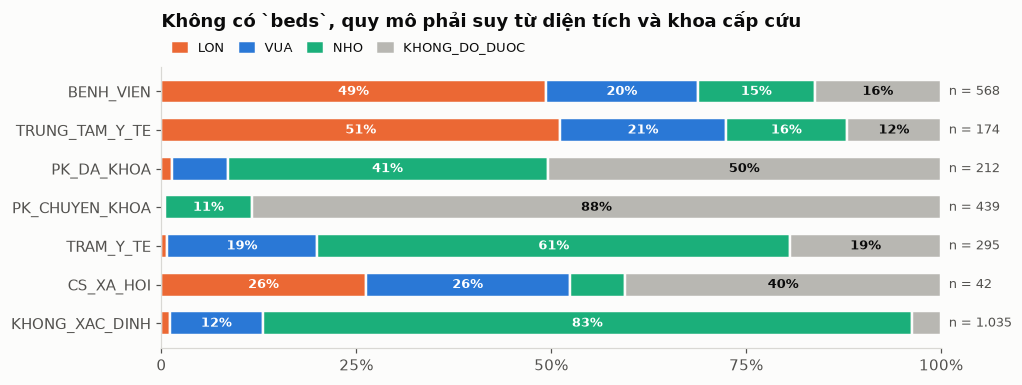

In [20]:
# [DATA] sinh cột: quy_mo_yt, container_uid, vai_tro, fragment_group
from shapely import wkb
from shapely.geometry import Point
from shapely.strtree import STRtree

# QUY MÔ — `beds` không tồn tại, nên dùng ba dấu vết gián tiếp, ghi rõ nguồn.
_dt = clean["area_m2"].fillna(0)
clean["quy_mo_yt"] = np.select(
    [clean["emergency"].eq("yes") | _dt.ge(10_000), _dt.ge(2_000), _dt.gt(0)],
    ["LON", "VUA", "NHO"],
    default="KHONG_DO_DUOC",
)
clean["quy_mo_nguon"] = np.select(
    [clean["emergency"].eq("yes"), _dt.gt(0)], ["cap_cuu", "dien_tich"], default="khong_co"
)
print(clean["quy_mo_yt"].value_counts().to_string())
print()
print(pd.crosstab(clean["loai_yt"], clean["quy_mo_yt"]).to_string())

# CỜ PHI LÂM SÀNG (thêm 2026-08-09). `healthcare=*` được nhận NGUYÊN KHOÁ ở bước 1 —
# đúng cái bẫy notebook vừa giảng cho `emergency`, mắc lại ở khoá bên cạnh. OSM xếp cả
# `hair` (tiệm tóc), `optometrist` (kính thuốc), `alternative`, `blood_donation` vào
# `healthcare`. Không XOÁ: chúng là cơ sở chăm sóc sức khoẻ theo lược đồ OSM và việc
# loại chúng là quyết định của downstream, không phải của lớp EDA. Chỉ CẮM CỜ để không
# ai đếm "Tiệm Tóc Chú Ba" là cơ sở khám chữa bệnh.
# HAI cờ, KHÔNG một. Lần gộp đầu tiên (2026-08-09) đã dán "phi lâm sàng" lên
# "Phòng khám Đông y PGS.TS. Vũ Nam" (`healthcare=alternative`) và "trạm xá"
# (`healthcare=podiatrist`) — cả hai đều SAI: y học cổ truyền và chân khoa là khám
# chữa bệnh có phép ở VN, chính hệ thống công còn có "Bệnh viện Y học cổ truyền".
# Bài học: "không phải bệnh viện" và "không phải y tế" là hai mệnh đề khác nhau.
#   `phi_lam_sang` — CHẮC CHẮN không phải khám chữa bệnh (tiệm tóc, kính thuốc).
#   `tham_my`      — thẩm mỹ / spa: ranh giới thật sự mờ (bệnh viện thẩm mỹ có phép
#                    phẫu thuật, spa thì không). Cắm cờ để downstream tự quyết,
#                    KHÔNG thay downstream quyết.
# `optometrist` ĐÃ BỊ RÚT khỏi danh sách tag (vòng đo thứ hai): OSM xếp cả "Kính Thuốc
# Điện Biên Phủ" (bán lẻ) lẫn "Trung tâm Mắt Kỹ thuật cao Nam Việt" và "Tuệ Anh Eye Care"
# (nhãn khoa lâm sàng) vào cùng một giá trị. Một tag gộp hai khái niệm thì không đủ để
# kết luận — phải có TÊN chống lưng. Chỉ `hair` là không thể hiểu nhầm.
# Và cờ này chỉ cắm khi KHÔNG có amenity lâm sàng tự khai: "Vietnamese Traditional
# Massage Institute" mang `amenity=clinic` là xoa bóp trị liệu, không phải tiệm massage.
# Nguyên tắc cho MỌI cờ dùng để LOẠI: thiếu bằng chứng thì KHÔNG cắm, vì downstream sẽ
# đọc cờ như một lời khẳng định.
HC_PHI_LAM_SANG = {"hair"}
PHI_LS_RX = r"\btiem toc\b|\bcat toc\b|\bsalon\b|kinh thuoc|mat kinh|\bmassage\b"
THAM_MY_RX = r"tham my|\bspa\b|\bbeauty\b|lam dep|\bnails?\b"
AMEN_LAM_SANG = ["hospital", "clinic", "doctors", "dentist"]
clean["phi_lam_sang"] = clean["healthcare"].isin(HC_PHI_LAM_SANG) | (
    clean["name_norm"].str.contains(PHI_LS_RX, na=False)
    & ~clean["amenity"].isin(AMEN_LAM_SANG)
)
clean["tham_my"] = clean["name_norm"].str.contains(THAM_MY_RX, na=False)
for _c in ["phi_lam_sang", "tham_my"]:
    print(f"\ncờ {_c}: {int(clean[_c].sum()):,} dòng")
    print("  ", clean.loc[clean[_c], "name"].dropna().head(8).tolist())

PTS = [Point(x, y) for x, y in zip(clean["lng"].values, clean["lat"].values)]
TREE = STRtree(PTS)
UIDS = clean["uid"].values
vung = clean[clean["is_area"] & clean["geometry_wkb"].notna()].copy()
vung["_geom"] = [wkb.loads(bytes(x)) for x in vung["geometry_wkb"]]
vung = vung[[g.is_valid and g.area > 0 for g in vung["_geom"]]]
container = {}
for i, geom in vung.sort_values("area_m2", ascending=False)["_geom"].items():
    self_uid = vung.at[i, "uid"]
    q = TREE.query(geom)
    if not len(q):
        continue
    for j in q[[geom.contains(PTS[k]) for k in q]]:
        if UIDS[j] != self_uid:
            container[UIDS[j]] = self_uid
clean["container_uid"] = clean["uid"].map(container)
clean["vai_tro"] = np.where(
    clean["container_uid"].notna(), "KHOA_TRONG_KHUON_VIEN", "CO_SO_DOC_LAP"
)
co_ten = clean["name"].notna()
key = clean.loc[co_ten, ["h3_r8", "name_norm"]].astype(str).agg("|".join, axis=1)
clean["fragment_group"] = key[key.duplicated(keep=False)].reindex(clean.index)

n_row, n_ct = len(clean), int(clean["container_uid"].notna().sum())
print(
    f"\ndòng nằm TRONG một polygon y tế khác (khoa/dãy nhà): {n_ct:,}"
    f"  → đếm CƠ SỞ: {n_row - n_ct:,} thay vì {n_row:,}"
)
print(
    f"nhóm trùng tên cùng ô H3: {clean['fragment_group'].nunique():,} nhóm,"
    f" {clean['fragment_group'].notna().sum():,} dòng"
)

fig, ax = plt.subplots(figsize=(9.4, 3.6))
QM = ["LON", "VUA", "NHO", "KHONG_DO_DUOC"]
QM_C = {"LON": ORANGE, "VUA": BLUE, "NHO": GREEN, "KHONG_DO_DUOC": GRAY}
LO = [c for c in LOAI_ORDER if c in set(clean["loai_yt"])]
tab = pd.crosstab(clean["loai_yt"], clean["quy_mo_yt"]).reindex(index=LO, columns=QM).fillna(0)
share = tab.div(tab.sum(axis=1), axis=0)
left = np.zeros(len(tab))
for q in QM:
    v = share[q].values
    ax.barh(tab.index, v, left=left, color=QM_C[q], height=0.62, edgecolor=BG, linewidth=1.6)
    for y, pp in enumerate(v):
        if pp > 0.08:
            ax.text(
                left[y] + pp / 2,
                y,
                f"{pp:.0%}",
                ha="center",
                va="center",
                fontsize=8.5,
                color="#ffffff" if q != "KHONG_DO_DUOC" else INK,
                fontweight="bold",
            )
    left += v
for y, ten in enumerate(tab.index):
    ax.text(1.01, y, f"n = {fmt(tab.loc[ten].sum())}", va="center", fontsize=8.5, color=MUTED)
ax.set_xlim(0, 1)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_xticklabels(["0", "25%", "50%", "75%", "100%"])
ax.invert_yaxis()
ax.grid(visible=False)
ax.set_title("Không có `beds`, quy mô phải suy từ diện tích và khoa cấp cứu", pad=26, loc="left")
ax.legend(
    handles=[plt.Rectangle((0, 0), 1, 1, color=QM_C[q]) for q in QM],
    labels=QM,
    ncol=4,
    loc="lower left",
    bbox_to_anchor=(0, 1.0),
    frameon=False,
    fontsize=8.5,
    handlelength=1.1,
    columnspacing=1.2,
)
fig.tight_layout()
plt.show()

## Bước 5 — FINAL và bộ CÒN LẠI

In [21]:
final = clean.copy()
out_final = EDA_DIR / f"poi_{LOP}_{SCOPE}_final.parquet"
final.drop(columns="tags_dict").to_parquet(out_final, index=False)
print(f"final: {len(final):,} dòng, {final.shape[1] - 1} cột → {out_final.name}")
print("\nloai_yt :", final["loai_yt"].value_counts().to_dict())
print("tuyen_yt:", final["tuyen_yt"].value_counts().to_dict())
print(f"số CƠ SỞ (lọc container_uid): {final['container_uid'].isna().sum():,}")
print()
print(
    final.groupby("loai_yt")["province_name"]
    .value_counts()
    .unstack(0)
    .fillna(0)
    .astype(int)
    .to_string()
)

final: 2,765 dòng, 86 cột → poi_benhvien_7tinh_final.parquet

loai_yt : {'KHONG_XAC_DINH': 1035, 'BENH_VIEN': 568, 'PK_CHUYEN_KHOA': 439, 'TRAM_Y_TE': 295, 'PK_DA_KHOA': 212, 'TRUNG_TAM_Y_TE': 174, 'CS_XA_HOI': 42}
tuyen_yt: {'KHONG_KHAI': 2202, 'PHUONG_XA': 272, 'QUAN_HUYEN': 97, 'TU_NHAN': 86, 'TINH_THANH': 60, 'TRUNG_UONG': 48}
số CƠ SỞ (lọc container_uid): 1,624

loai_yt                BENH_VIEN  CS_XA_HOI  KHONG_XAC_DINH  PK_CHUYEN_KHOA  PK_DA_KHOA  TRAM_Y_TE  TRUNG_TAM_Y_TE
province_name                                                                                                     
Thành phố Cần Thơ             55          7              39             119          16         28              16
Thành phố Hà Nội             171         11             616              96          56        105              28
Thành phố Hải Phòng           49          4              42              21           4          9              27
Thành phố Hồ Chí Minh        188         15            

In [22]:
da_thuoc_lop = set(final["uid"])
con_lai = poi[~poi["uid"].isin(da_thuoc_lop)].copy()
out_pool = EDA_DIR / f"poi_extended_{SCOPE}_con_lai_sau_{LOP}.parquet"
con_lai.drop(columns="tags_dict").to_parquet(out_pool, index=False)
print(f"bộ vào    : {len(poi):,}")
print(f"đã bóc ra : {len(da_thuoc_lop):,}")
print(f"CÒN LẠI   : {len(con_lai):,}  → {out_pool.name}")
_con = removed["uid"].isin(con_lai["uid"]).sum()
assert _con == len(removed), f"mất {len(removed) - _con} dòng bị luật xoá khỏi bộ còn lại"
print(
    f"✓ {len(removed):,} dòng bị {removed['drop_reason'].nunique()} luật xoá đều nằm lại trong bộ còn lại"
)
for ten_lop in ["chungcu", "luutru", "thuongmai", "giaitri", "thamquan", "truonghoc"]:
    f = EDA_DIR / f"poi_{ten_lop}_{SCOPE}_final.parquet"
    giao = set(pq.read_table(f, columns=["uid"]).to_pandas()["uid"]) & da_thuoc_lop
    assert not giao, f"{len(giao)} uid trùng với lớp {ten_lop}"
    print(f"✓ không đếm đôi với lớp {ten_lop}")

_td = con_lai["tags"].map(parse_tags)
print("\nnguyên liệu lớp HÀNH CHÍNH trong bộ còn lại:")
print(
    "  office=government:",
    _td.map(lambda t: t.get("office")).eq("government").sum(),
    "| government=*:",
    _td.map(lambda t: t.get("government")).notna().sum(),
    "| amenity=townhall/police/courthouse:",
    _td.map(lambda t: t.get("amenity")).isin(["townhall", "police", "courthouse"]).sum(),
)

bộ vào    : 150,712
đã bóc ra : 2,765
CÒN LẠI   : 147,947  → poi_extended_7tinh_con_lai_sau_benhvien.parquet


✓ 1,963 dòng bị 5 luật xoá đều nằm lại trong bộ còn lại
✓ không đếm đôi với lớp chungcu
✓ không đếm đôi với lớp luutru
✓ không đếm đôi với lớp thuongmai
✓ không đếm đôi với lớp giaitri
✓ không đếm đôi với lớp thamquan
✓ không đếm đôi với lớp truonghoc



nguyên liệu lớp HÀNH CHÍNH trong bộ còn lại:
  office=government: 1384 | government=*: 740 | amenity=townhall/police/courthouse: 1285


In [23]:
# [DATA] sinh file: poi_benhvien_{SCOPE}_thieu_bang_chung.parquet
# ĐO RECALL BẰNG NHÂN CHỨNG NGOÀI LỚP.
#
# Recall tuyển (bước 1) và recall luật xoá (bước 3) đều đo được từ bên trong, và cả hai
# đều gần 100%. Nhưng cả hai đều chỉ trả lời "ta có bỏ sót thứ CÓ TRONG NGUỒN không".
# Câu hỏi thật là: nguồn có bỏ sót không — và ta có cách nào biết?
#
# CÓ. LUẬT 1 xoá 505 trạm buýt mang tên cơ sở y tế ("Trạm y tế xã Đốc Tín"). Xoá là ĐÚNG:
# một node `highway=bus_stop` không phải cơ sở. Nhưng cái TÊN là một NHÂN CHỨNG ĐỘC LẬP —
# ai đó đặt tên trạm theo một cơ sở có thật ở đó. Nếu trong bán kính 1 km không có cơ sở
# nào trong `final`, thì cơ sở đó TỒN TẠI mà OSM chưa vẽ.
# Đây là cùng một mẹo với "tên là mốc tham chiếu" của chuỗi, nhưng đọc NGƯỢC: thay vì dùng
# nó để LOẠI, dùng nó để ĐO cái mình không có.
from scipy.spatial import cKDTree

_ht = removed[removed["drop_reason"].eq("HA_TANG_DUONG")].copy()
_ht = _ht[
    _ht["name_norm"].str.contains(
        r"benh vien|\bbv \b|trung tam y te|tram y te|phong kham|nha khoa|\bttyt\b", na=False
    )
]
_xy = lambda d: np.c_[
    d["lng"].values * np.cos(np.radians(d["lat"].values)) * 111_320,
    d["lat"].values * 111_320,
]
_ht["kc_m"] = cKDTree(_xy(final)).query(_xy(_ht))[0].round(0)


def _loi_ten(s):
    s = re.sub(r"^(doi dien|truoc cong|truoc|he truoc|he doi dien|ben canh|duong vao|qua san|qua|cong|cach)\s+", "", s)
    s = re.sub(r"\s*\d+\s*m\b.*", "", s)
    s = re.sub(r"\s*-\s*.*", "", s)
    m = re.search(r"(benh vien|trung tam y te|tram y te|phong kham|nha khoa)[a-z0-9 ]*", s)
    return (m.group(0).strip() if m else s.strip())[:40]


_ht["co_so"] = _ht["name_norm"].map(_loi_ten)
BAN_KINH_M = 1_000  # 1 km — trạm buýt luôn đặt ở cổng; xa hơn thì tên chỉ là mốc vùng
thieu = _ht[_ht["kc_m"] > BAN_KINH_M].sort_values("kc_m", ascending=False)
thieu_gom = thieu.drop_duplicates("co_so")

print(f"trạm hạ tầng mang tên cơ sở y tế: {len(_ht):,}")
for _r in (200, 500, 1_000):
    print(f"  có cơ sở trong final cách ≤ {_r:5,} m: {(_ht['kc_m'] <= _r).mean():6.1%}")
n_cs = int(final["container_uid"].isna().sum())
print(
    f"\n→ {len(thieu_gom)} CƠ SỞ có nhân chứng nhưng VẮNG trong final"
    f" ({thieu_gom['name_norm'].str.contains('tram y te').sum()} là trạm y tế xã)"
)
print(f"→ RECALL LỚP = {n_cs:,}/{n_cs + len(thieu_gom):,} = {n_cs / (n_cs + len(thieu_gom)):.2%}")
print(thieu_gom["province_name"].value_counts().to_string())

out_thieu = EDA_DIR / f"poi_{LOP}_{SCOPE}_thieu_bang_chung.parquet"
thieu_gom[["name", "name_norm", "co_so", "lat", "lng", "kc_m", "province_name", "uid"]].to_parquet(
    out_thieu, index=False
)
print(f"\n→ {out_thieu.name}: danh sách soi tay / bổ sung nguồn, có sẵn toạ độ")


trạm hạ tầng mang tên cơ sở y tế: 457
  có cơ sở trong final cách ≤   200 m:  59.7%
  có cơ sở trong final cách ≤   500 m:  71.1%
  có cơ sở trong final cách ≤ 1,000 m:  77.5%

→ 67 CƠ SỞ có nhân chứng nhưng VẮNG trong final (42 là trạm y tế xã)
→ RECALL LỚP = 1,624/1,691 = 96.04%
province_name
Thành phố Hà Nội         28
Thành phố Hồ Chí Minh    20
Tỉnh Đồng Nai             7
Thành phố Cần Thơ         5
Thành phố Đà Nẵng         5
Thành phố Hải Phòng       2

→ poi_benhvien_7tinh_thieu_bang_chung.parquet: danh sách soi tay / bổ sung nguồn, có sẵn toạ độ


---

## ✅ CHỐT LỚP Y TẾ

> ⏳ **SỐ LIỆU TRANG NÀY SẼ SINH LẠI SAU LẦN CHẠY TỚI.** Chuỗi chạy lại từ lớp 3;
> bản vá lớp *thamquan* trả **~34 bệnh viện lớn** (Quân y 175, Nhi Trung ương…) về
> lớp này, nên **mọi con số dòng / cơ sở / bảng phân bố bên dưới sẽ đổi**. Chúng là
> số đo của lần chạy trên đầu vào 150.708 dòng — giữ làm vết đối chiếu, đừng trích
> dẫn cho tới khi notebook chạy lại và mục này được sinh lại.

Đầu ra: `data/qa/eda/poi_benhvien_7tinh_final.parquet` (+ `..._con_lai_sau_benhvien.parquet`).

| Cột | Nghĩa |
| --- | --- |
| `loai_yt` | `BENH_VIEN` · `TRUNG_TAM_Y_TE` · `PK_DA_KHOA` · `PK_CHUYEN_KHOA` · `TRAM_Y_TE` · `CS_XA_HOI` (bảo trợ xã hội, **không phải KCB**) · `KHONG_XAC_DINH` |
| `tuyen_yt` | `TRUNG_UONG` · `TINH_THANH` · `QUAN_HUYEN` · `PHUONG_XA` · `TU_NHAN` · `KHONG_KHAI` — **vuông góc với `loai_yt`** |
| `quy_mo_yt` / `quy_mo_nguon` | `LON`/`VUA`/`NHO`/`KHONG_DO_DUOC`; nguồn là `cap_cuu` hay `dien_tich` |
| `loai_xung_dot` | `amenity` và `healthcare` bất đồng — 4 dòng |
| `phi_lam_sang` | CHẮC CHẮN không phải KCB: tiệm tóc, kính thuốc, massage — **đếm cơ sở KCB thì lọc** |
| `tham_my` | thẩm mỹ / spa — ranh giới mờ, cắm cờ để downstream tự quyết |
| `container_uid` / `vai_tro` | khoa/dãy nhà trong khuôn viên bệnh viện — **đếm CƠ SỞ thì lọc** |

### Chất lượng đo được — RECALL ba tầng, và PRECISION

Recall của một dây chuyền bóc lớp KHÔNG phải một con số. Có ba câu hỏi khác nhau, và
chỉ câu thứ ba là con số nên đem đi dùng.

**Tầng 1 — bước TUYỂN có bỏ sót gì trong nguồn không?**

| phép đo | phạm vi | kết quả |
| --- | --- | --- |
| 4 đầu dò CỨNG, cổng recall tầng 2 | 145.980 dòng chưa từng vào lớp | **0** |
| Từ vựng lâm sàng ĐỘC LẬP (5 nhóm, không token nào nằm trong `YT_RX`) | 145.980 dòng | 14 khả nghi → soi tay **0 sót thật** |
| Mẫu ngẫu nhiên 300 dòng có tên từ bộ bỏ lại (seed 42) | ~62.700 dòng có tên | **0 sót**, Wilson 95% ≤ 1,3% |

14 dòng khả nghi đều loại đúng: "Sở Y tế Hà Nội"/"Bộ Y tế" (cơ quan → lớp hành chính),
5 spa mang chữ "Health", 2 doanh nghiệp "Medical", "Cấp Cứu Bờ Biển số 2" (chòi cứu hộ),
"An Phước Trị Liệu Cơ Xương Khớp" (`shop=massage`).

**Tầng 2 — 5 LUẬT XOÁ có giết nhầm cơ sở thật không?** *(đây là tầng đáng lo nhất — bước 3
xoá 1.963/4.728 dòng, tức 41,5% những gì đã tuyển)*

Định nghĩa "cơ sở thật" độc lập với luật: có tag y tế cứng **và** không mang tag hạ tầng đường.

```
cơ sở y tế thật vào bước 3      : 4.067
  bị xoá bởi CẮT PHẠM VI (chủ đích, nhà thuốc + thú y) : 1.324
  bị xoá NGOÀI Ý                                       :     2
RECALL bước 3 (hiệu lực) = 99,93%
```

Hai dòng mất ngoài ý là "Phòng y tế" và "Phong y te DHCT" (`amenity=clinic`) — cơ quan
hành chính bị OSM gắn tag phòng khám. Chúng nằm trong `b3_bi_xoa`, tra được bằng
`drop_reason`, và đã được bàn giao sang lớp hành chính. **Không có bệnh viện nào bị mất.**

LUẬT 1 (`HA_TANG_DUONG`, 505 dòng) là luật nghi ngờ nhất vì xoá 303 dòng có chữ "bệnh viện"
trong tên. Kiểm chứng: **505/505 mang `highway`+`public_transport`, 0 dòng có tag y tế cứng,
0 dòng là polygon.** Toàn bộ là trạm buýt. Xoá đúng.

**Tầng 3 — NGUỒN có bỏ sót không? Đây là con số nên đem đi dùng.**

Chính 505 trạm buýt bị xoá lại là **nhân chứng độc lập**: ai đó đặt tên trạm theo một cơ sở
có thật ở đó. Nếu trong bán kính 1 km không có cơ sở nào trong `final` thì cơ sở ấy tồn tại
mà OSM chưa vẽ.

```
trạm buýt mang tên cơ sở y tế              : 457
  có cơ sở trong final cách ≤ 200 m        : 59,7%
  ≤ 1 km                                   : 77,5%
→ 67 CƠ SỞ có nhân chứng nhưng VẮNG MẶT (42 là trạm y tế xã)

RECALL LỚP = 1.624 / 1.691 = 96,0%
```

**4,0% thiếu hụt này là khuyết của NGUỒN, không phải lỗi của luật** — không quy tắc nào
tuyển được thứ không có trong dữ liệu. Nó lệch có cấu trúc: **42/67 là trạm y tế xã**, tập
trung ở ngoại thành Hà Nội (28) và TP.HCM (20). Nghĩa là lớp này **thiếu hụt ở nông thôn
nhiều hơn đô thị**, và con số đó sẽ xấu đi ở 27 tỉnh chưa chạy.

Đã xuất thành sản phẩm: `poi_benhvien_7tinh_thieu_bang_chung.parquet` — 67 dòng, có tên
và toạ độ, dùng để soi tay hoặc đối chiếu danh mục Bộ Y tế.

**PRECISION — mẫu 50 CƠ SỞ ĐỘC LẬP (seed 7), soi từng dòng**

| câu hỏi | kết quả | Wilson 95% |
| --- | --- | --- |
| Dòng có thuộc lớp y tế / bảo trợ không? | **49/50 = 98,0%** | 89,5–99,6% |
| Nhãn `loai_yt` có đúng không? | **47/50 = 94,0%** | 83,8–97,9% |

Một dòng ngoài lớp: "Nhà Ba Chi (Trường Gà)" — tag rác `amenity=nursing_home` đơn độc,
**đã mang nhãn `CS_XA_HOI`** nên không lọt vào phép đếm cơ sở KCB nào. Ba dòng sai nhãn
thuộc một pattern duy nhất còn lại — xem lỗi #12.

**KẾT LUẬN CHẤT LƯỢNG: ĐẠT.** Recall luật xoá 99,93%, recall lớp 96,0% với phần thiếu
được đo, được giải thích và được xuất thành danh sách; precision 98,0% mức lớp và 94,0%
mức nhãn, mọi dòng sai còn lại đều có cột cờ để lọc.

### Con số đáng giá: **99,8%**

Hai họ tag `amenity` và `healthcare` nhất trí **1.853/1.857** (99,8%). Cao hơn cả lớp trường học
(96,7%), và có lý do: hai lược đồ này do **cùng một người map** điền trong cùng một lần
sửa, nên chúng ít độc lập hơn cặp "tên vs tag" của lớp trường học. **Con số cao hơn KHÔNG
có nghĩa là dữ liệu tốt hơn** — nó có nghĩa là phép đo yếu hơn. Ghi rõ để không ai đọc
ngược. Bốn dòng bất đồng đều là ranh giới thật sự mờ (`clinic` ↔ `doctors`, nha khoa gắn
`hospital`).

### Lỗi CÒN LẠI

**Sai số ảnh hưởng tới con số cuối**

1. **Đếm dòng ≠ đếm cơ sở: 1.141/2.767 dòng (41%) là KHOA hoặc DÃY NHÀ bên trong khuôn
   viên bệnh viện.** Con số dùng được là **1.626 cơ sở**.
2. **`loai_yt = KHONG_XAC_DINH` (1.035) là nhóm lớn nhất** — chủ yếu là dãy nhà vô danh
   trong khuôn viên, cùng bệnh với lớp trường học. Hà Nội chiếm 616/1.035, lệch vì độ chi
   tiết map chứ không vì số cơ sở.
3. **`tuyen_yt = KHONG_KHAI` chiếm 80%.** Thang tuyến đọc từ tên, mà phần lớn tên không nói
   tuyến. Trục này **chỉ dùng được cho nhóm có khai**, đừng suy diễn phần còn lại.
4. **Quy mô là SUY LUẬN.** `beds` = 0 dòng trong toàn bộ dữ liệu VN.

10. **Bậc `TINH_THANH` đã sửa: 4 → 60 dòng.** Bản đầu đòi "bệnh viện" đứng SÁT
    "tỉnh/thành phố", nên "Bệnh viện **Mắt** Thành phố Hồ Chí Minh" rơi xuống
    `QUAN_HUYEN`. Bậc tỉnh rỗng vì LỖI, không vì thiếu khai — loại sai nguy hiểm nhất
    vì nó trông giống một phát hiện. Thang mới đối chiếu **danh mục 34 tỉnh/thành**
    đọc từ `store/admin/provinces.parquet` + 31 tên trước sáp nhập.
11. **`CS_XA_HOI` (44 dòng) tách khỏi `TRUNG_TAM_Y_TE`.** Trại trẻ mồ côi, Làng trẻ em
    SOS, bếp ăn từ thiện KHÔNG phải cơ sở khám chữa bệnh. Trước đây cả 56 dòng
    `amenity=social_facility` bị map thẳng thành `TRUNG_TAM_Y_TE`.
    `amenity=nursing_home` (OSM đã khai tử) chỉ đúng 1/8 — 7 dòng còn lại là
    "Nhà Ba Chi (Trường Gà)", "Rẫy", "Massaga Trường Giang".

**Giới hạn của NGUỒN**

5. **`beds` (số giường bệnh) hoàn toàn vắng mặt.** Thước quy mô chuẩn của ngành y tế không
   tồn tại trong OSM VN — đúng cảnh `rooms` ở lớp lưu trú và `capacity:students` ở lớp
   trường học. **Ba lớp, ba thước quy mô ngành, cả ba đều trống.** Đây là phát hiện chung
   của chuỗi, không phải sự cố riêng lớp nào.
6. **KHOÁ ≠ KHÁI NIỆM — ba lần trong cùng một lớp.** `emergency` (dưới đây),
   `healthcare` (gộp `hair`, `optometrist` — xem cờ `phi_lam_sang`) và
   `social_facility` (gộp trại mồ côi với viện dưỡng lão — xem `CS_XA_HOI`).
   Mỗi lần chữa đều là: đọc GIÁ TRỊ, và khi giá trị cũng sai thì đọc TÊN. Nó phủ trụ nước chữa cháy, chòi
   cứu hộ bãi biển, máy khử rung gắn tường — 160 dòng, không dòng nào là cơ sở y tế. Phải
   đọc GIÁ TRỊ; và ngay cả giá trị cũng chưa đủ — `defibrillator` là một THIẾT BỊ,
   `emergency_ward_entrance` là một CỬA VÀO. Ba vòng lọc mới còn lại `ambulance_station`.

**Chưa đo / chưa chốt**

7. **1.339 nhà thuốc + 54 cơ sở thú y đã bị cắt khỏi phạm vi** (1.393 dòng,
   `drop_reason == "NGOAI_PHAM_VI_NHA_THUOC_THU_Y"`).
   Đây là dữ liệu thật và là một lớp đáng làm riêng — nhà thuốc là điểm dừng ngắn, đều đặn,
   hồ sơ cầu sạc khác hẳn bệnh viện.
8. **Chưa tách công / tư.** `operator:type` phủ dưới 1%. Bệnh viện tư và bệnh viện công có
   hồ sơ đỗ xe rất khác nhau.
9. **Precision chưa đo bằng thước ngoài** (danh mục cơ sở khám chữa bệnh của Bộ Y tế).

12. **Tàn dư của bẫy "TÊN thắng TAG": 2 + 8 dòng.** `loai_yt` đọc TÊN trước TAG (đúng
    trong đa số ca), nhưng khi tên chứa tên của một cơ sở KHÁC thì nó thua: 2 dòng
    `amenity=pharmacy` mang nhãn `BENH_VIEN` ("Nhà thuốc Bệnh viện Quân y 7B"), 8 dòng
    thẩm mỹ mang nhãn `BENH_VIEN`/`PK_DA_KHOA` (Kangnam, Emcas, Gangwhoo…).
    **Cả 8 dòng thẩm mỹ đã có cờ `tham_my`** — lọc được. Hai dòng nhà thuốc thì chưa.
    Cùng họ với lỗi thú y đã vá; cố ý dừng ở đây vì mỗi lần cho TAG thắng TÊN lại phá
    một ca khác ("Bệnh viện Vạn Phước" cũng mang `amenity=pharmacy` nhưng là bệnh viện thật).
13. **9 dòng `hospital_* stories N` mang `vai_tro = CO_SO_DOC_LAP`.** Đây là mảnh nhà từ
    import 3D, lẽ ra phải là `KHOA_TRONG_KHUON_VIEN` nhưng polygon cha không tồn tại trong
    lớp. Ảnh hưởng: số CƠ SỞ 1.624 đang **thừa tối đa 9** (0,6%).

### CHỐT SỔ

> **Niên bản số liệu:** mọi con số dưới đây đo trên `poi_extended_7tinh_con_lai_sau_truonghoc.parquet`
> **150.708 dòng**. Lớp trên (`thamquan`, `truonghoc`) chạy lại thì các con số này đổi theo —
> đã chứng kiến một lần: 150.821 → 150.708 làm `final` 2.767 → 2.765. Notebook TÁI LẬP ĐƯỢC
> (hai lần chạy cho hash uid trùng khít); cái đổi là ĐẦU VÀO. Đọc số nào thì kèm số dòng đầu vào.


Đầu ra: `data/qa/eda/poi_benhvien_7tinh_final.parquet` — **2.765 dòng / 86 cột**
(+ `poi_extended_7tinh_con_lai_sau_benhvien.parquet`, 147.943 dòng, cho lớp hành chính).
Mọi bước sau **đọc `final`**, không đọc `b1`/`b3` nữa.

| `loai_yt` | dòng | ghi chú |
| --- | --- | --- |
| `KHONG_XAC_DINH` | 1.035 | 89% là dãy nhà vô danh trong khuôn viên — **lọc `container_uid`** |
| `BENH_VIEN` | 568 | 8 dòng thẩm mỹ có cờ `tham_my`, 2 dòng là nhà thuốc trong BV (lỗi #12) |
| `PK_CHUYEN_KHOA` | 439 | |
| `TRAM_Y_TE` | 295 | |
| `PK_DA_KHOA` | 212 | |
| `TRUNG_TAM_Y_TE` | 174 | |
| `CS_XA_HOI` | 42 | **KHÔNG phải cơ sở KCB** — trại mồ côi, làng SOS, bảo trợ xã hội |

`tuyen_yt`: `KHONG_KHAI` 2.202 · `PHUONG_XA` 272 · `QUAN_HUYEN` 97 · `TU_NHAN` 86 ·
`TINH_THANH` 60 · `TRUNG_UONG` 48
`quy_mo_yt`: `NHO` 1.291 · `KHONG_DO_DUOC` 721 · `LON` 397 · `VUA` 356
(nguồn: `dien_tich` 1.950 · `khong_co` 721 · `cap_cuu` 94)
Cờ: `tham_my` 21 · `loai_xung_dot` 4 · `mixed_use` 3 · `phi_lam_sang` 3

**Ba con số dùng được, theo thứ tự ưu tiên:**

1. **1.624 CƠ SỞ** (`container_uid.isna()`) — không phải 2.765 dòng. Trừ tiếp 42 `CS_XA_HOI`
   nếu chỉ đếm khám chữa bệnh → **1.582**.
2. **568 bệnh viện + 174 TTYT + 212 PKĐK = 954** cơ sở thuộc phạm vi đề bài
   ("bệnh viện, phòng khám lớn"), trước khi lọc `container_uid`.
3. **60 cơ sở tuyến tỉnh/thành + 48 tuyến trung ương** — dùng được sau khi thang `TUYEN_YT`
   được viết lại theo danh mục hành chính. **Đừng suy diễn 2.204 dòng `KHONG_KHAI`.**

**Ba việc KHÔNG được làm với file này:**
- Đếm dòng thay cho đếm cơ sở (sai 70%).
- Dùng `CS_XA_HOI` hoặc dòng có cờ `tham_my`/`phi_lam_sang` trong thống kê cơ sở KCB.
- Dùng cơ cấu `tuyen_yt` như một phân bố — 80% không khai, phần khai bị thiên lệch về
  cơ sở lớn có tên đầy đủ.

### Bàn giao cho lớp HÀNH CHÍNH

- **Đã chuyển giao:** "Sở Y tế", "Phòng Y tế quận" (`drop_reason == "CO_QUAN_QUAN_LY_YT"`),
  cùng nhóm với "Phòng Giáo dục & Đào tạo" của lớp trường học. Hai lớp đã dọn sẵn phần cơ
  quan quản lý NGÀNH; lớp hành chính chỉ còn phần cơ quan HÀNH CHÍNH chung.
- **Trục ĐỐI CHỨNG CHÉO có dùng lại được không?** Lớp hành chính có `office=government`,
  `government=*` và `amenity=townhall|police|courthouse` — ba họ tag chồng nhau. Nhưng
  chúng KHÔNG song song như `amenity`/`healthcare`: `government=tax` và `amenity=townhall`
  mô tả hai thứ khác nhau. **Phải đo trước khi coi là đối chứng.**
- **Cảnh báo về `operator`:** hai lớp liên tiếp đã trả giá cho việc đọc `operator` như loại
  công trình ("Hầm giữ xe" do đại học vận hành; "Nhà Tang lễ Quốc gia" do bệnh viện vận
  hành). Lớp hành chính sẽ gặp nó nặng nhất, vì **mọi thứ ở VN đều có một cơ quan nhà nước
  đứng tên vận hành**. `operator` là CHỦ SỞ HỮU, không phải LOẠI.